In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from storer import Storer
import seaborn as sns
import torch
import einops

In [2]:
# d_mlp = 16
storer = Storer("/modal_volume/mtsp_results/metrics/")
storer.add_datestamp_prefix()


# from train_mtsp_model_and_not_not import TrainConfig, AndNotNotDataset

# storer.add_prefix(f"train_mtsp_model_and_not_not/v1/")

from train_mtsp_model_uniform_task_distribution_modal import TrainConfig

storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/")

config = TrainConfig(seed=0)


# storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/{config.cache_key()}")


storer.add_prefix(f"{config.cache_key()}")

torch.manual_seed(config.seed)
model = MultitaskSparseParityModel(
    d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
)
dataset = MultitaskSparseParityDataset(
    n_control_bits=config.n_control_bits,
    n_task_bits=config.n_task_bits,
    n_xored_bits=config.n_xored_bits,
    task_distribution_decay_rate=config.task_distribution_decay_rate,
    batch_sz=config.batch_sz,
    size=config.steps,
)

# dataset = AndNotNotDataset(
#     n_control_bits=config.n_control_bits,
#     n_task_bits=config.n_task_bits,
#     n_xored_bits=config.n_xored_bits,
#     task_distribution_decay_rate=config.task_distribution_decay_rate,
#     batch_sz=config.batch_sz,
#     size=config.steps,
# )
storer.add_prefix(f"model/{config.steps}")
key = "model"
assert storer.exists(key), storer
model.load_state_dict(storer.read(key))
losses_by_step_and_task: np.ndarray = storer.read("losses_by_step_and_task")

torch.manual_seed(0)
task_ids, task_bits, parity = dataset.get_batch(batch_sz=1024)
logits = model((task_ids, task_bits, ()))
val_loss = F.cross_entropy(logits, parity)
print(val_loss)

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor(0.3048, grad_fn=<NllLossBackward0>)


In [3]:
dataset.selected_bits_by_task

tensor([[ 7, 17],
        [22, 26]])

In [3]:
l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

In [4]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum(), (neuron_mask).sum()

(tensor(0), tensor(14))

In [5]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [6]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
# x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x1 = torch.cat([torch.ones_like(task_ids).unsqueeze(1), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([ 18.1826, -12.5944, -15.4796,  14.7313, -15.6755,  11.6087,  10.4058,
        -13.5893, -13.2177,  11.8071,  12.6060, -17.2788,  12.6521, -13.5657,
        -14.9867,  17.5027])

In [7]:
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
out = model((task_ids, task_bits, ()))
out[:, 0] - out[:, 1]

tensor([ 18.1826, -12.5944, -15.4795,  14.7313, -15.6755,  11.6087,  10.4057,
        -13.5893, -13.2177,  11.8071,  12.6060, -17.2788,  12.6521, -13.5657,
        -14.9867,  17.5027], grad_fn=<SubBackward0>)

In [8]:
torch.ones_like(task_ids)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [9]:
x1

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 0., 1., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 0., 0., 1., 0.],
        [1., 1., 0., 1., 0.],
        [1., 0., 1., 1., 0.],
        [1., 1., 1., 1., 0.],
        [1., 0., 0., 0., 1.],
        [1., 1., 0., 0., 1.],
        [1., 0., 1., 0., 1.],
        [1., 1., 1., 0., 1.],
        [1., 0., 0., 1., 1.],
        [1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

In [10]:
F.binary_cross_entropy_with_logits(x4, ((1 + bits.sum(-1)) % 2).float())

tensor(3.8385e-06)

<Axes: >

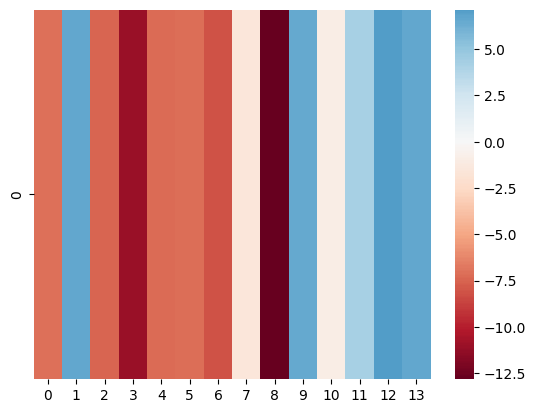

In [11]:
sns.heatmap((l2_synth[neuron_mask])[None], cmap="RdBu", center=0)

()

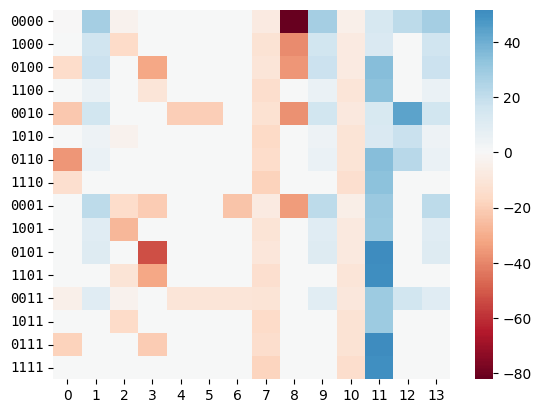

In [12]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

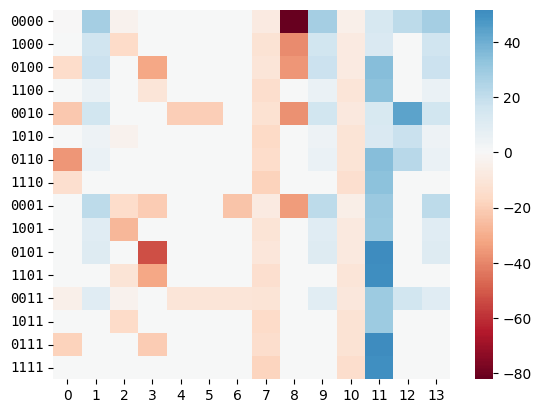

In [13]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
# out = model((task_ids, task_bits, ()))
# out[:, 0] - out[:, 1]

x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

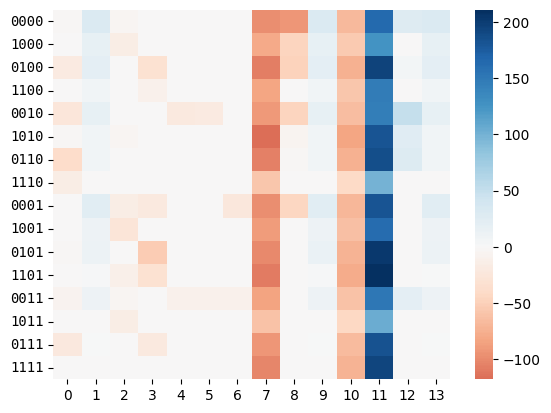

In [14]:
for task_id in range(config.n_control_bits):
    task_ids = torch.tensor(task_id).repeat(2**config.n_xored_bits)
    # task_bits = torch.ones((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
    # task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits))
    task_bits = torch.randint(2, (2**config.n_xored_bits, config.n_task_bits)).float()
    task_bits[:, dataset.selected_bits_by_task[task_id]] = bits.float()
    # out = model((task_ids, task_bits, ()))
    # out[:, 0] - out[:, 1]

    x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
    x2 = model.l1(x1)
    x3 = F.relu(x2)
    x4 = model.l2(x3)
    x1 = x1.detach()
    x2 = x2.detach()
    x3 = x3.detach()
    x4 = x4.detach()

    bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
    ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
    ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
    ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
    plt.show()

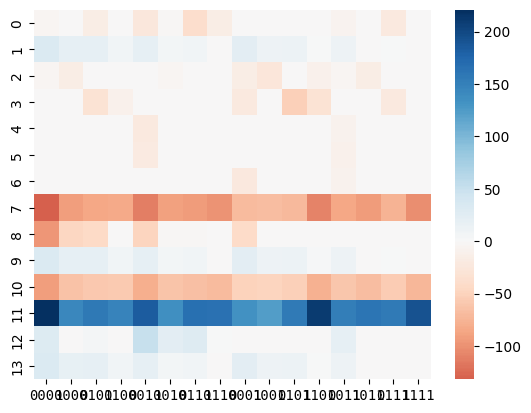

In [15]:
for task_id in range(config.n_control_bits):
    task_ids = torch.tensor(task_id).repeat(2**config.n_xored_bits)
    # task_bits = torch.ones((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
    # task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits))
    task_bits = torch.randint(2, (2**config.n_xored_bits, config.n_task_bits)).float()
    task_bits[:, dataset.selected_bits_by_task[task_id]] = bits.float()
    # out = model((task_ids, task_bits, ()))
    # out[:, 0] - out[:, 1]

    x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
    x2 = model.l1(x1)
    x3 = F.relu(x2)
    x4 = model.l2(x3)
    x1 = x1.detach()
    x2 = x2.detach()
    x3 = x3.detach()
    x4 = x4.detach()

    bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
    ax = sns.heatmap((x3 * l2_synth[neuron_mask]).T, cmap="RdBu", center=0)
    ax.set_xticks(np.arange(len(bit_labels)) + 0.5)
    ax.set_xticklabels(bit_labels, rotation=0, fontfamily="monospace")
    plt.show()

## almost linear neuron merge - unfinished

In [16]:
# almost_linear_neuron_idxs = []

# for i in range(model.d_mlp):
#     if (model.l1.weight[i][config.n_control_bits :] >= 0).all() and (
#         model.l1.weight[i][: config.n_control_bits].min()
#         > -model.l1.weight[2][config.n_control_bits :].max()
#     ):
#         almost_linear_neuron_idxs.append(i)
# almost_linear_neuron_idxs = torch.tensor(almost_linear_neuron_idxs)
# almost_linear_neuron_idxs

In [17]:
# #unfinished, was working 2026.03.13 on merging together some

# non_linear_neurons_mask = torch.ones((model.d_mlp,)).bool()
# non_linear_neurons_mask[almost_linear_neuron_idxs] = False

# merged_d_mlp = model.d_mlp - almost_linear_neuron_idxs.size(0) + 1

# l1_weights_with_almost_linear_neurons_merged = torch.zeros(
#     (merged_d_mlp, model.l1.weight.data.size(1))
# )
# # l1_weights_with_almost_linear_neurons_merged[0] = model.l1.weight.data[
# #     almost_linear_neuron_idxs
# # ].sum(0)

# l1_weights_with_almost_linear_neurons_merged[0] = model.l1.weight.data[
#     almost_linear_neuron_idxs
# ] * l2_synth[almost_linear_neuron_idxs].unsqueeze(1)
# l1_weights_with_almost_linear_neurons_merged[1:] = model.l1.weight.data[non_linear_neurons_mask]
# l2_synth_with_almost_linear_neurons_merged = torch.zeros((merged_d_mlp,))
# l2_synth_with_almost_linear_neurons_merged[0] = l2_synth[almost_linear_neuron_idxs].sum(0)
# # l2_synth_with_almost_linear_neurons_merged[0] = torch.tensor(1)

# l2_synth_with_almost_linear_neurons_merged[1:] = l2_synth[non_linear_neurons_mask]



In [18]:
# model.l1.weight.data[almost_linear_neuron_idxs] * l2_synth[almost_linear_neuron_idxs].unsqueeze(1)

In [19]:
# l2_synth[almost_linear_neuron_idxs].unsqueeze(0)

In [20]:
# # x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
# # x2 = model.l1(x1)
# # x3 = F.relu(x2)
# # x4 = model.l2(x3)
# # x1 = x1.detach()
# # x2 = x2.detach()
# # x3 = x3.detach()
# # x4 = x4.detach()
# # # F.cross_entropy(x4, (bits.sum(-1) % 2).long())

# x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
# x2 = model.l1(x1)
# x3 = F.relu(x2)
# x4 = x3 @ l2_synth.T
# x1 = x1.detach()
# x2 = x2.detach()
# x3 = x3.detach()
# x4 = x4.detach()


# # x2 = x1 @ l1_weights_with_almost_linear_neurons_merged.T
# # x3 = F.relu(x2)
# # x4 = x3 @ l2_synth_with_almost_linear_neurons_merged.T
# # x1 = x1.detach()
# # x2 = x2.detach()
# # x3 = x3.detach()
# # x4 = x4.detach()
# # F.binary_cross_entropy_with_logits(x4, (bits.sum(-1) % 2).float())
# x4

In [21]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0]

In [22]:
F.relu(x1 @ model.l1.weight.data.T)[0]

tensor([6.3619e-01, 4.7321e+00, 5.2424e-01, 3.9004e-07, 3.1349e-07, 5.4994e-07,
        0.0000e+00, 8.4118e+01, 7.4834e+00, 4.7805e+00, 9.4651e+01, 5.2379e+01,
        4.1751e+00, 4.7145e+00])

In [23]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [24]:
# F.relu(input=x1 @ model.l1.weight.data.T)[0, non_linear_neurons_mask]

In [25]:
# F.relu(input=x1 @ model.l1.weight.data.T)[0]

In [26]:
# q = torch.cat(
#     (
#         F.relu(input=x1 @ model.l1.weight.data.T)[0][almost_linear_neuron_idxs].sum(0).unsqueeze(0),
#         F.relu(input=x1 @ model.l1.weight.data.T)[0][non_linear_neurons_mask],
#     )
# )

In [27]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0] - q

In [28]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0]

In [29]:
# l1_weights_with_almost_linear_neurons_merged[0]

In [30]:
# model.l1.weight.data[almost_linear_neuron_idxs]

In [31]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0][almost_linear_neuron_idxs].sum()

In [32]:
# F.relu(input=x1 @ model.l1.weight.data.T) @ l2_synth.T

In [33]:
# x2[0]

In [34]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [35]:
# l2_synth

In [36]:
# l2_synth_with_almost_linear_neurons_merged

In [37]:
# F.relu(x2[0]).sum()

In [38]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0].sum()

In [39]:
#

In [40]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [41]:
# x4

In [42]:
# x3.shape, l2_synth_with_almost_linear_neurons_merged.shape

In [43]:
# x1.shape, x2.shape

In [44]:
#

In [45]:
# x2.shape

In [46]:
# task_bits

In [47]:
#

In [48]:
# x4

In [49]:
# sns.heatmap(l1_weights_with_almost_linear_neurons_merged, cmap="RdBu", center=0)

## .

<Axes: >

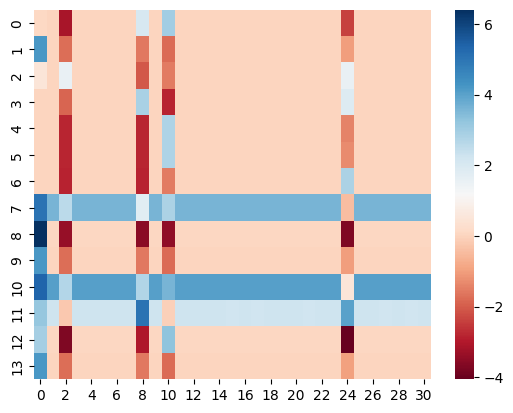

In [50]:
sns.heatmap(model.l1.weight.data, cmap="RdBu")

In [51]:
(x3 * l2_synth[neuron_mask])[:, [2, 7, 8]].sum(1)

tensor([-231.6037, -153.4835, -128.5880,  -82.7949, -162.6854,  -95.7136,
         -94.8701,  -97.8627, -126.0628,  -94.3423,  -71.7861, -121.1551,
         -88.5892, -109.8078,  -76.2275, -102.7806])

In [52]:
k = config.n_xored_bits + config.n_control_bits

bits_all = (
    torch.floor(torch.arange(2 ** (k)).unsqueeze(1) / (2 ** (k - 1 - torch.arange((k))))) % 2
).long()

In [53]:
bits_all.shape

torch.Size([32, 5])

()

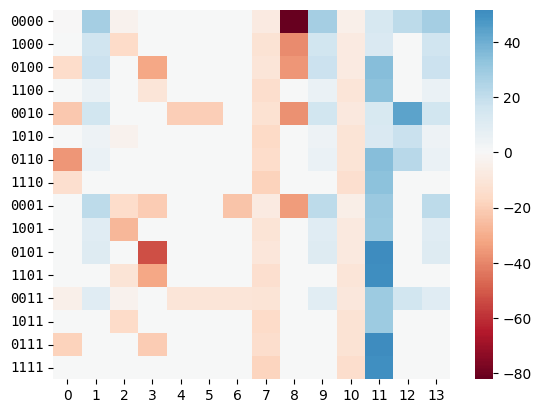

In [54]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
# out = model((task_ids, task_bits, ()))
# out[:, 0] - out[:, 1]

x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [55]:
(
    torch.randn((config.n_control_bits, config.n_task_bits))
    .sort()
    .indices[:, : config.n_xored_bits]
    .sort()
    .values
)

tensor([[ 9, 15, 22, 28]])

In [56]:
# x1[5]

In [57]:
# model.l1(x1)[5, 1]

In [58]:
# (model.l1.weight.data[1] * x1[5]).sum()
# (model.l1.weight.data[1] * x1[5])

In [59]:
# model.l1.weight.data[1]

In [60]:
# x3[5]

<Axes: >

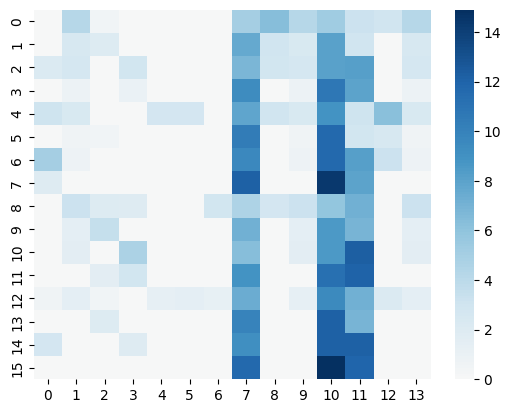

In [61]:
sns.heatmap(x3, cmap="RdBu", center=0)

In [62]:
# (x3 * l2_synth[neuron_mask])[7]

In [63]:
x4

tensor([[-105.2516, -123.4342],
        [-116.9457, -104.3513],
        [-140.4992, -125.0196],
        [-125.2552, -139.9865],
        [-155.7789, -140.1033],
        [-123.7623, -135.3710],
        [-154.8374, -165.2432],
        [-166.8305, -153.2412],
        [-116.1096, -102.8920],
        [-107.8473, -119.6544],
        [-125.1417, -137.7477],
        [-150.1206, -132.8418],
        [-123.9911, -136.6432],
        [-138.0551, -124.4894],
        [-160.5638, -145.5771],
        [-161.2773, -178.7800]])

()

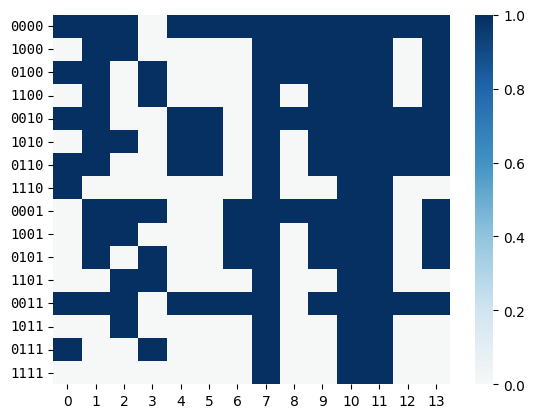

In [64]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x2 > 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

<Axes: >

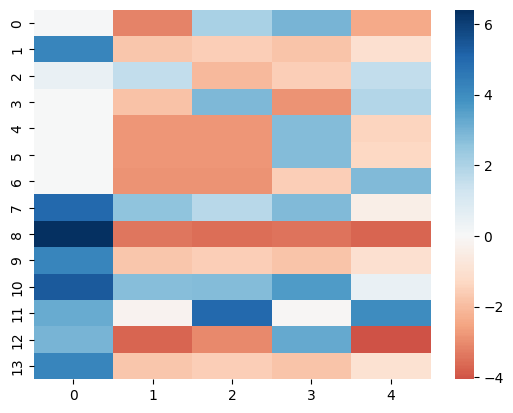

In [65]:
##
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

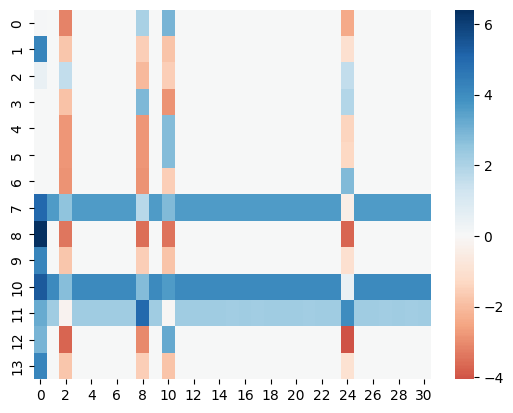

In [66]:
sns.heatmap(data=model.l1.weight.data, cmap="RdBu", center=0)

In [67]:
l2_synth[neuron_mask]

tensor([ -7.0777,   6.6143,  -7.4673, -11.0933,  -7.2485,  -7.1922,  -8.2255,
         -1.5656, -12.8281,   6.5728,  -0.9743,   4.2158,   7.1277,   6.6199])

In [68]:
neuron_mask = ~(l2_synth.abs() < 0.03)

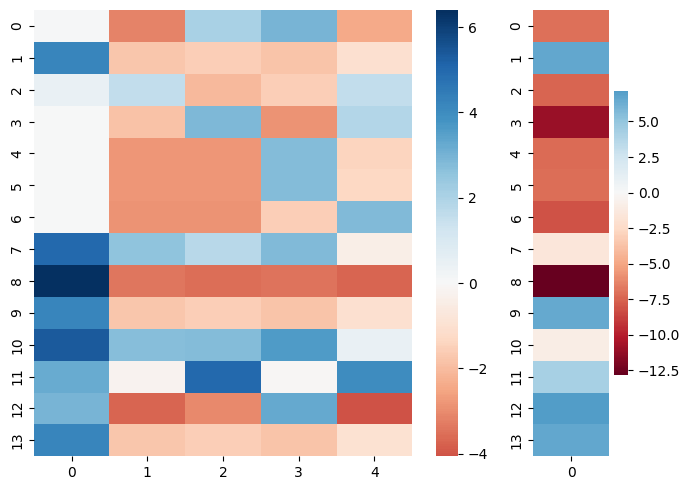

In [69]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0, ax=ax1)
sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
plt.tight_layout()

In [70]:
dataset.selected_bits_by_task

tensor([[ 1,  7,  9, 23]])

In [71]:
# l1_for_tasks = model.l1.weight.data[:, dataset.selected_bits_by_task.sort(1).values.reshape(-1)]

In [72]:
input_idxs = torch.cat(
    (
        torch.arange(config.n_control_bits).unsqueeze(1),
        dataset.selected_bits_by_task.sort(1).values,
    ),
    dim=1,
)
l1_for_tasks = model.l1.weight.data[:, input_idxs.reshape(-1)]
input_idxs

tensor([[ 0,  1,  7,  9, 23]])

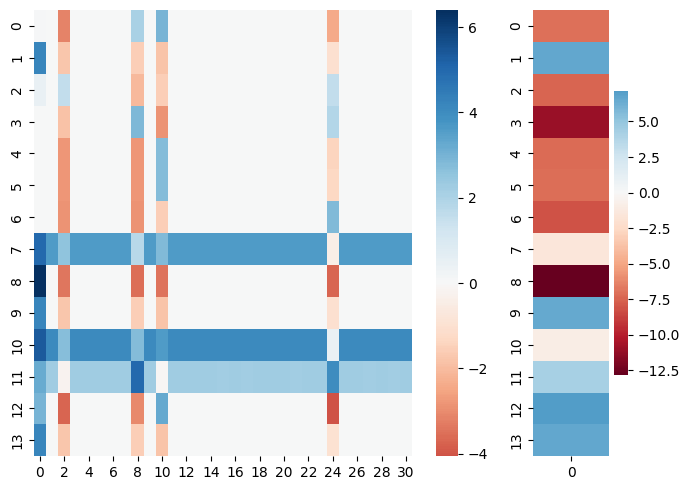

In [73]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(data=model.l1.weight.data, cmap="RdBu", center=0, ax=ax1)
# sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
plt.tight_layout()

In [74]:
rows = model.l1.weight.data
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>6}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:6.2f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

        col0  col1  col2  col3  col4  col5  col6  col7  col8  col9 col10 col11 col12 col13 col14 col15 col16 col17 col18 col19 col20 col21 col22 col23 col24 col25 col26 col27 col28 col29 col30
row0    0.08  0.03 -3.13  0.03  0.03  0.03  0.03  0.03  2.04  0.03  2.98  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03 -2.40  0.03  0.03  0.03  0.03  0.03  0.03
row1    4.20  0.02 -1.75  0.02  0.02  0.02  0.02  0.02 -1.60  0.02 -1.79  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02 -0.99  0.02  0.02  0.02  0.02  0.02  0.02
row2    0.50  0.00  1.55  0.00  0.00  0.00  0.00  0.00 -2.06  0.00 -1.54  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.54  0.00  0.00  0.00  0.00  0.00  0.00
row3   -0.00  0.00 -1.89  0.00  0.00  0.00  0.00  0.00  2.85  0.00 -2.85  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.89  0.00  0.00  0.00  0.00  0.00  0.00
row4    0.00 -0.00 -2.79 -0.00 -0.0

In [75]:
dataset.selected_bits_by_task

tensor([[ 1,  7,  9, 23]])

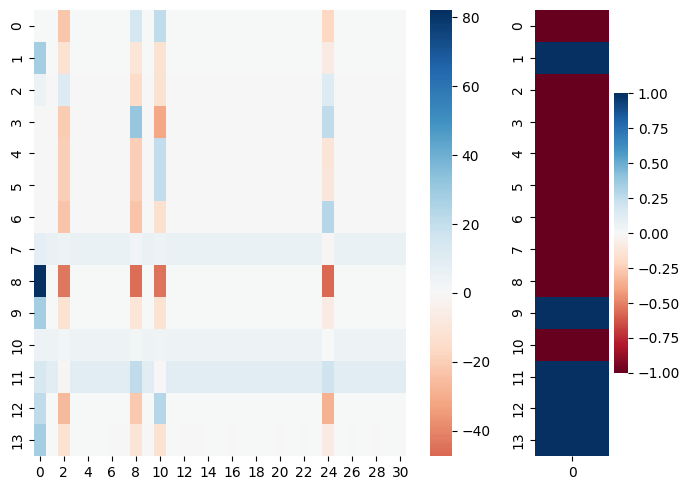

In [76]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(
    data=model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1),
    cmap="RdBu",
    center=0,
    ax=ax1,
)
# sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
sns.heatmap(
    data=(l2_synth[neuron_mask].unsqueeze(1) > 0).float() * 2 - 1, cmap="RdBu", center=0, ax=ax2
)
plt.tight_layout()

In [76]:
import os

In [77]:
save_weight_step_paths = sorted(
    [x for x in os.listdir(storer.root_path) if x.startswith("step=")],
    key=lambda x: int(x[len("step=") :]),
)

/var/folders/wx/_0nb6bps4412h7hz73r6_4fw0000gp/T/ipykernel_45488/2667137891.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(


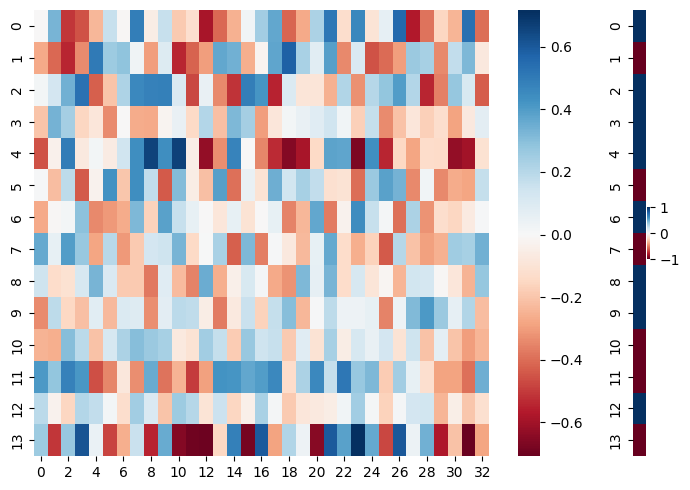

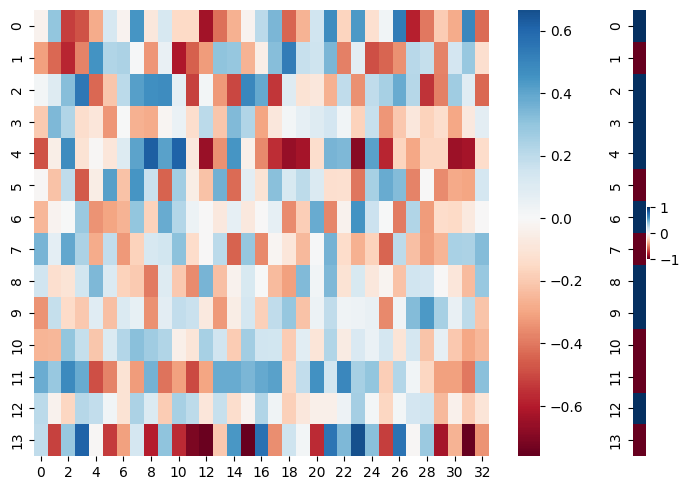

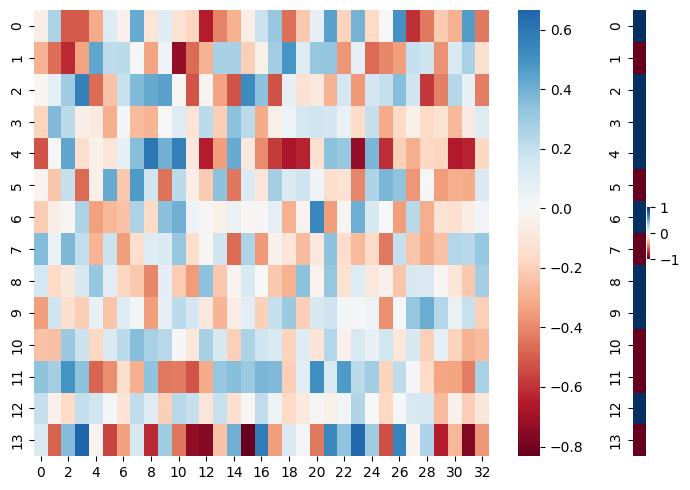

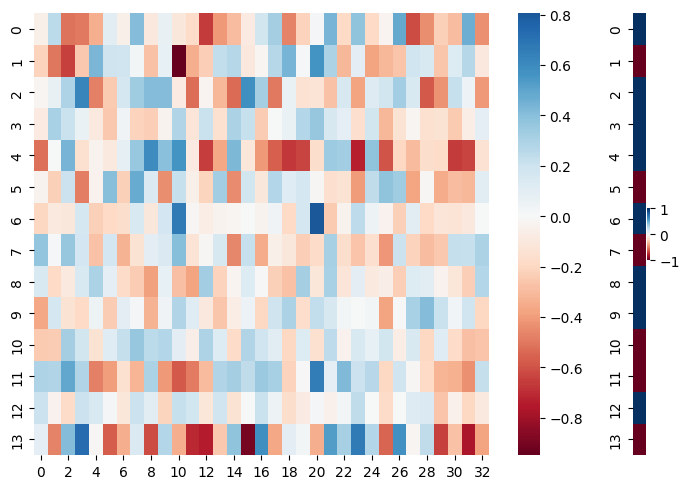

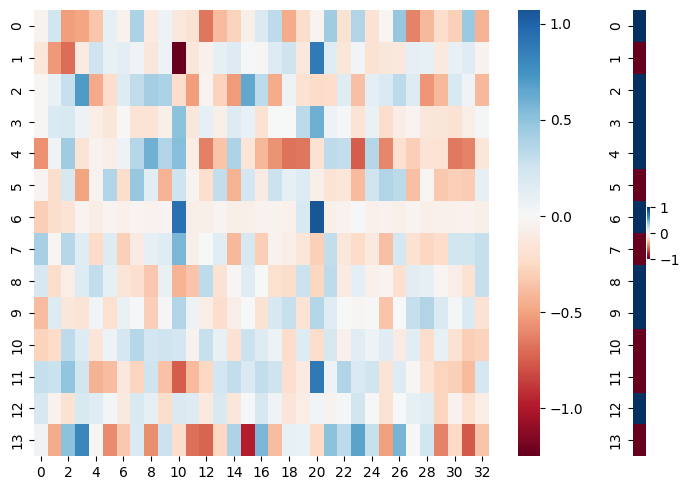

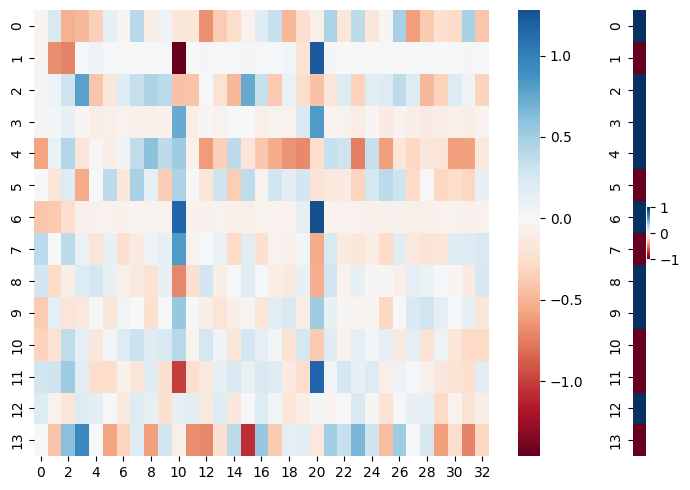

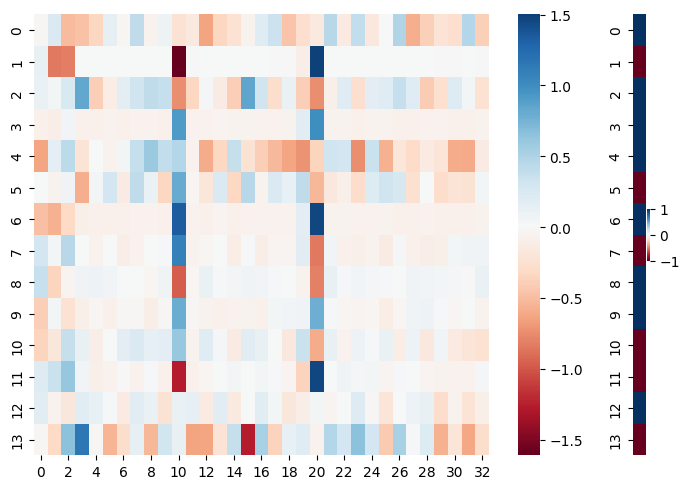

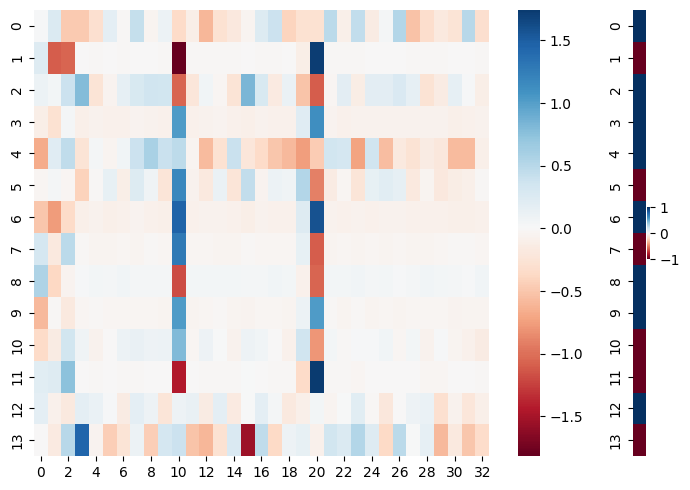

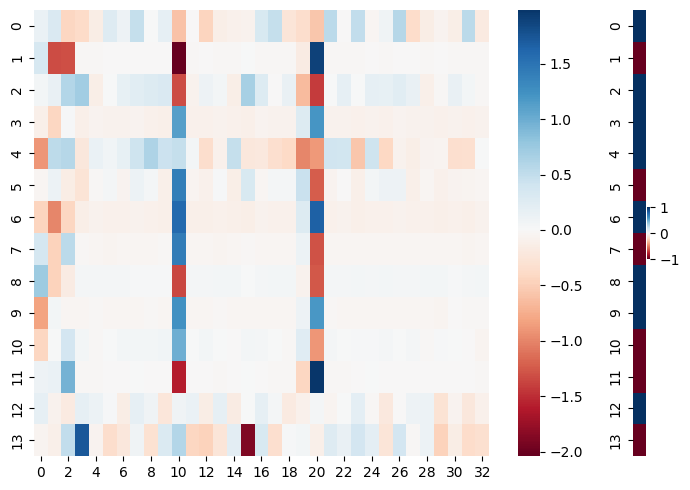

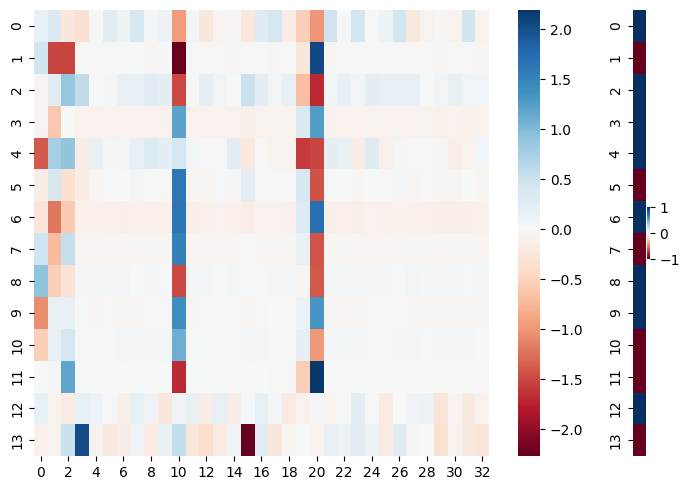

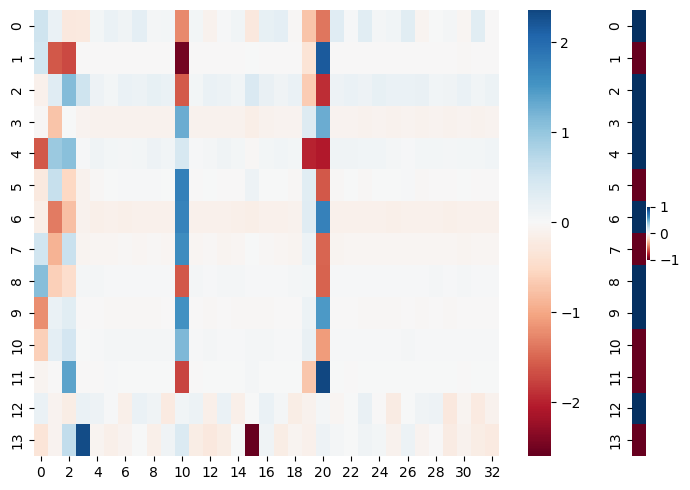

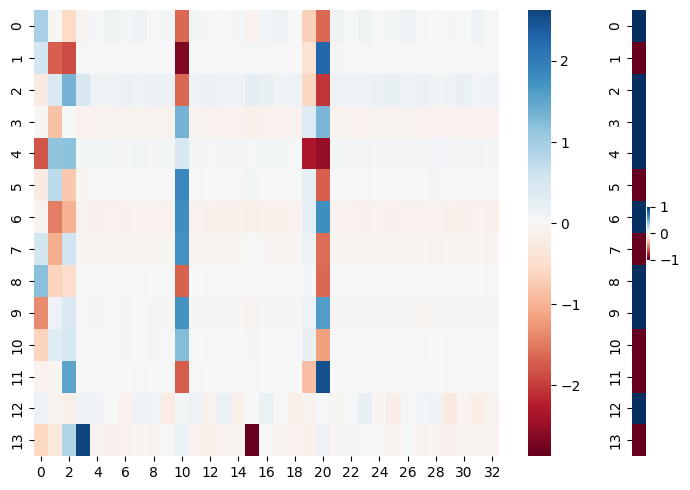

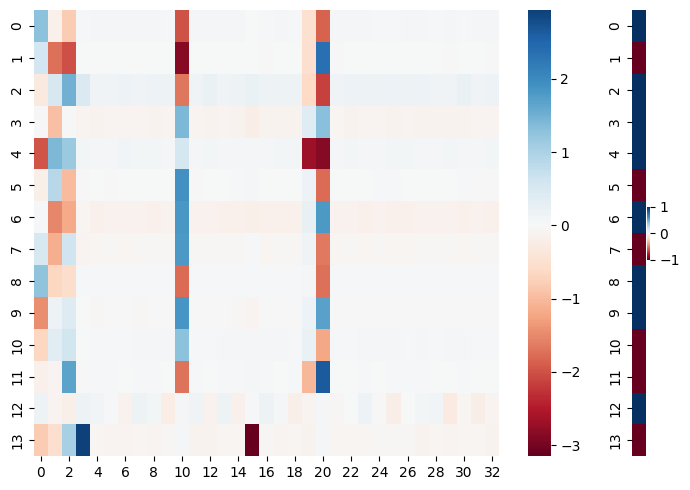

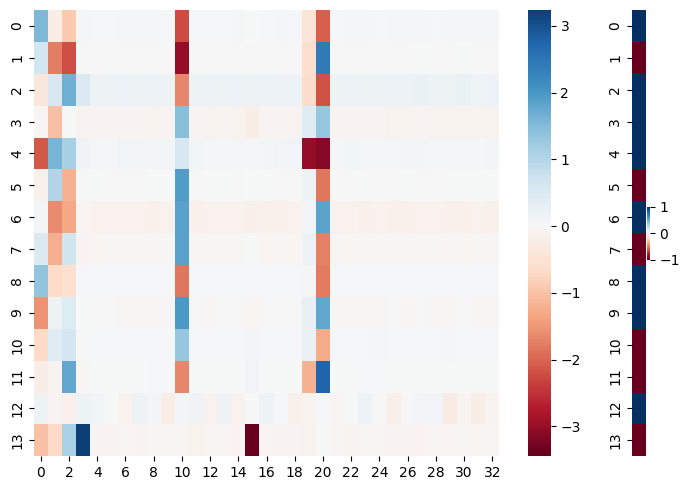

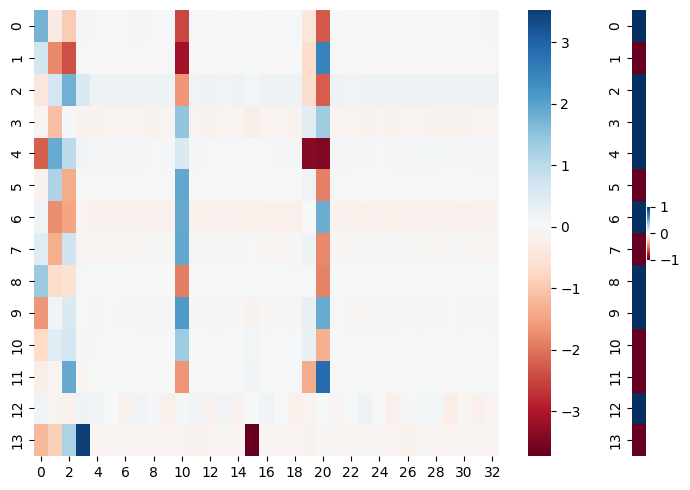

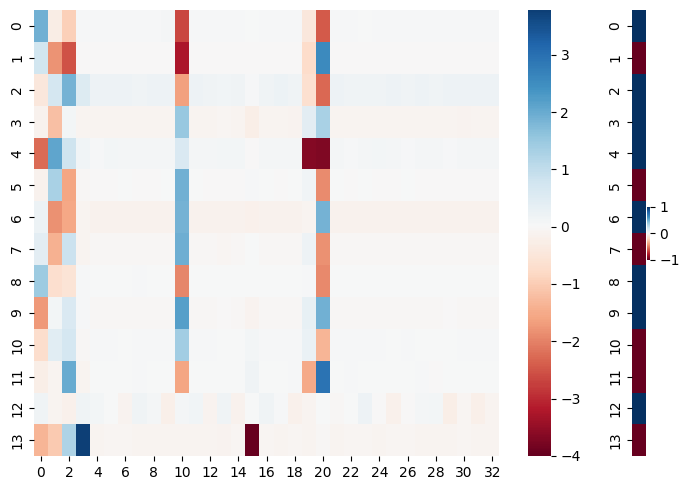

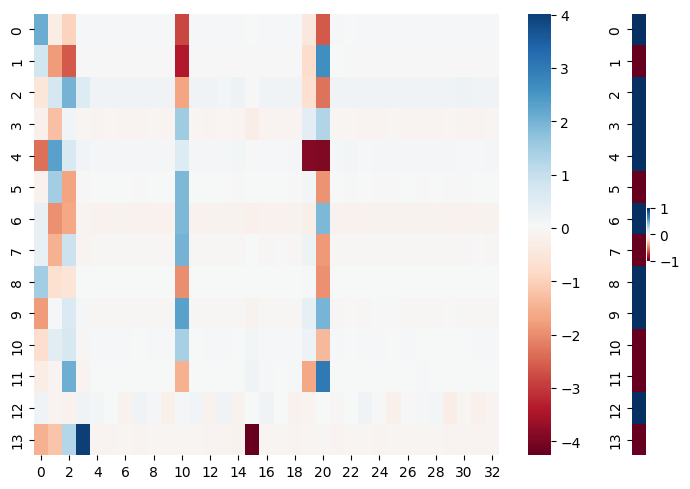

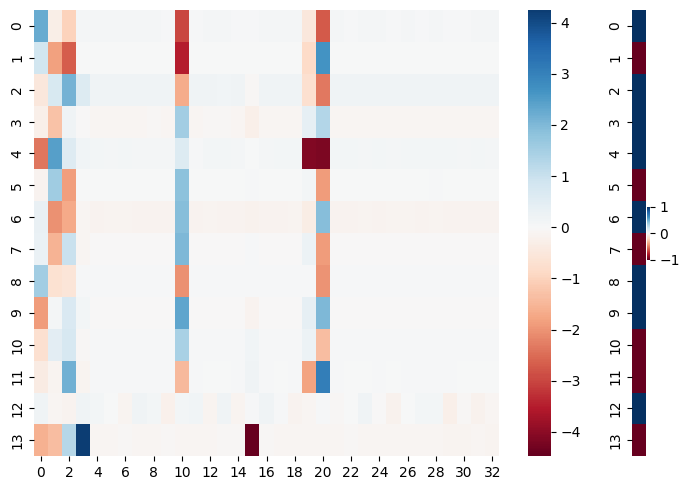

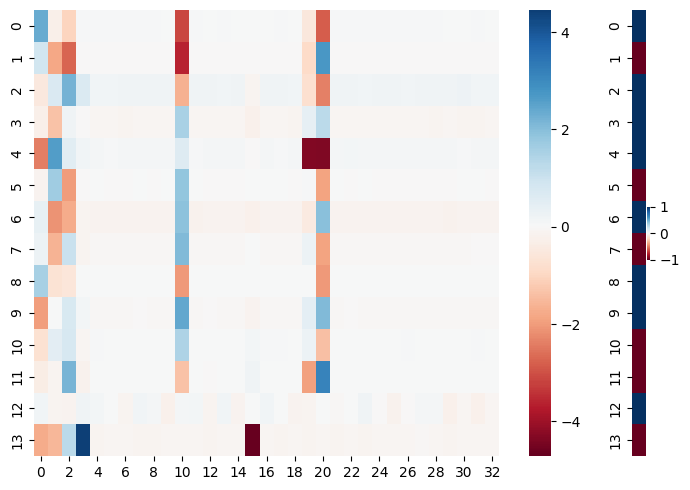

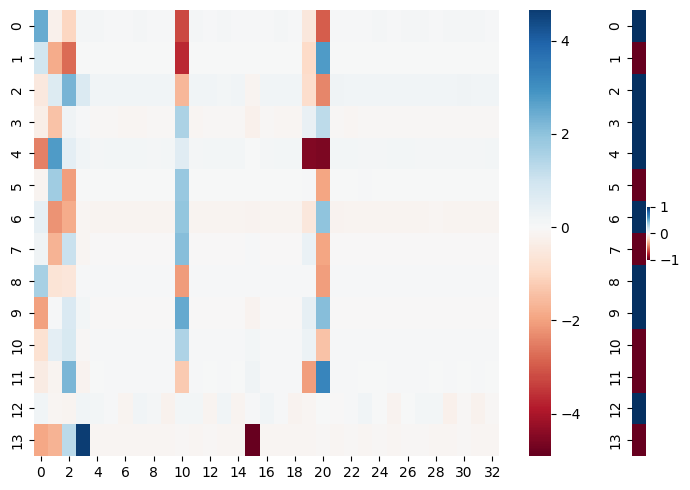

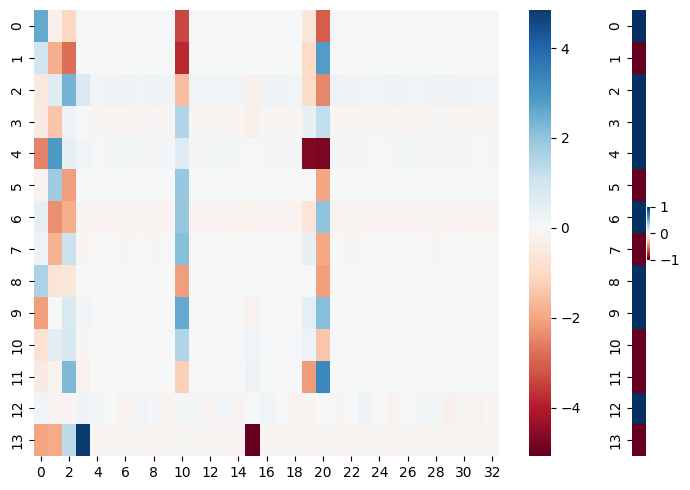

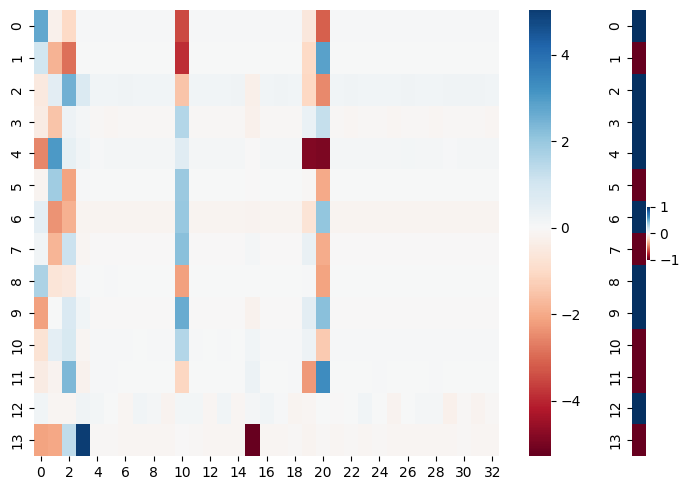

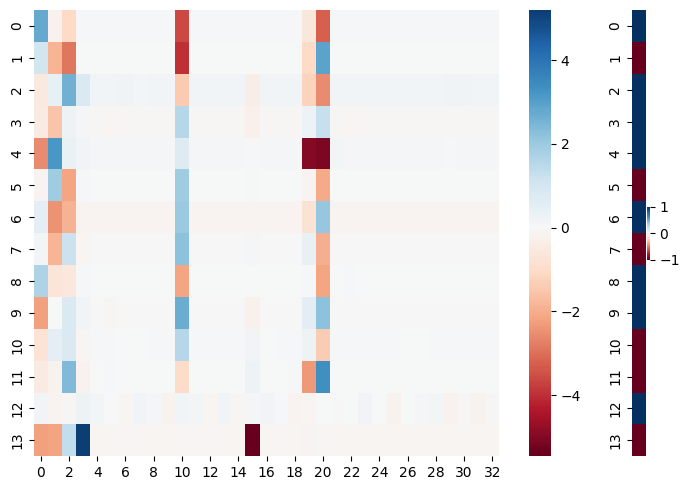

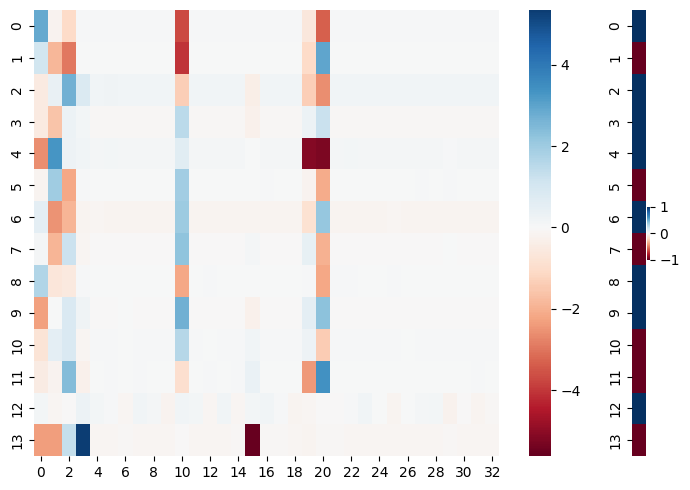

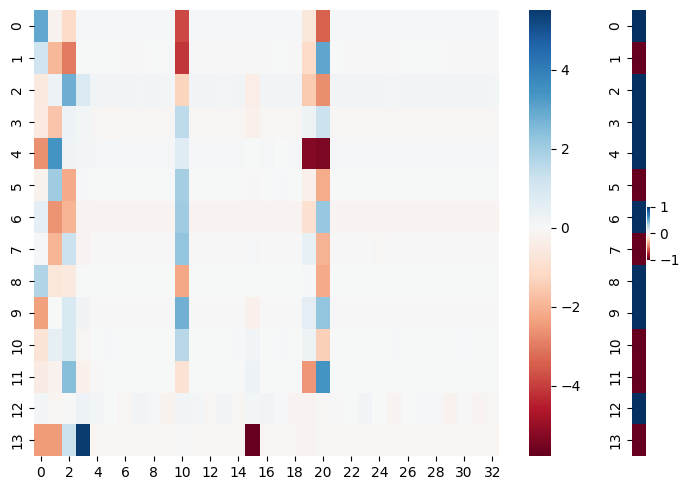

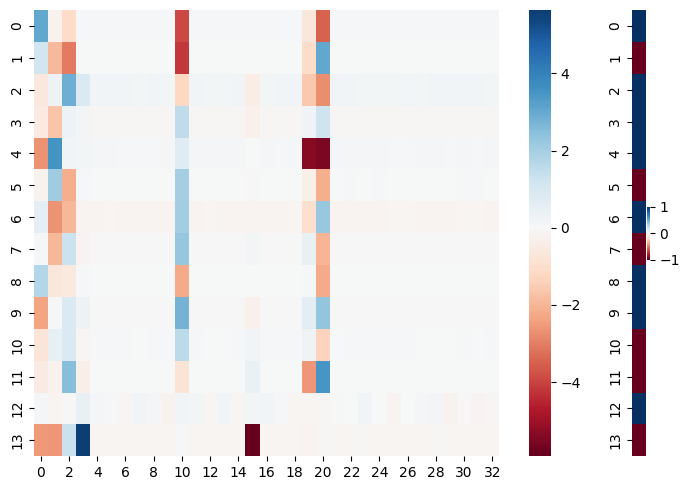

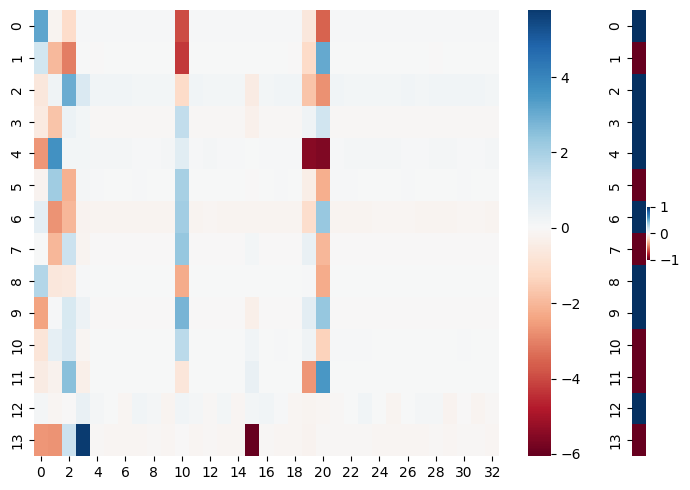

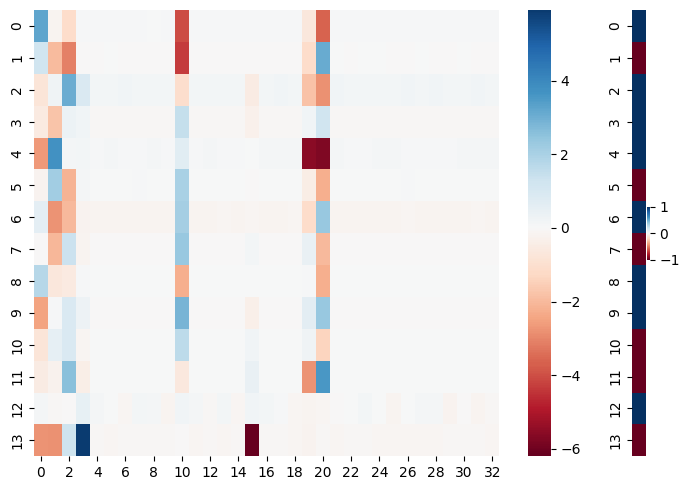

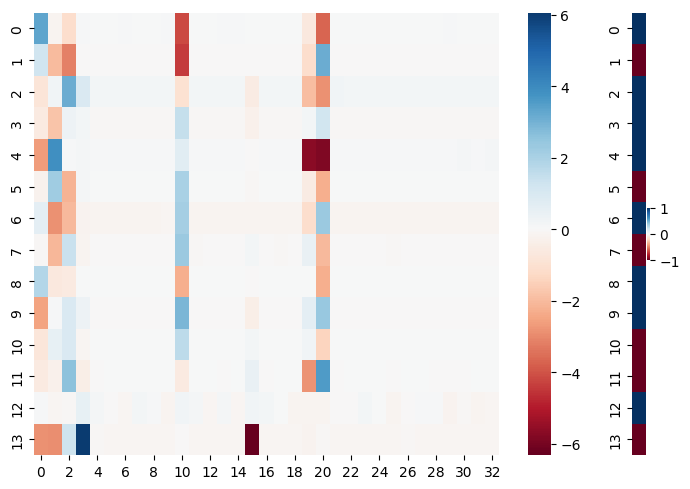

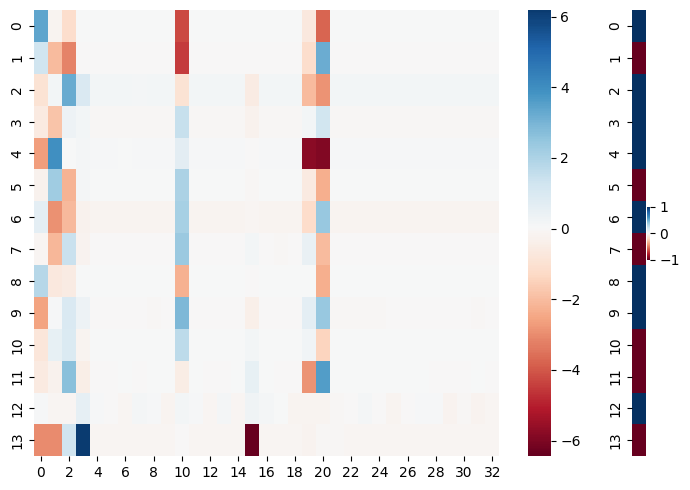

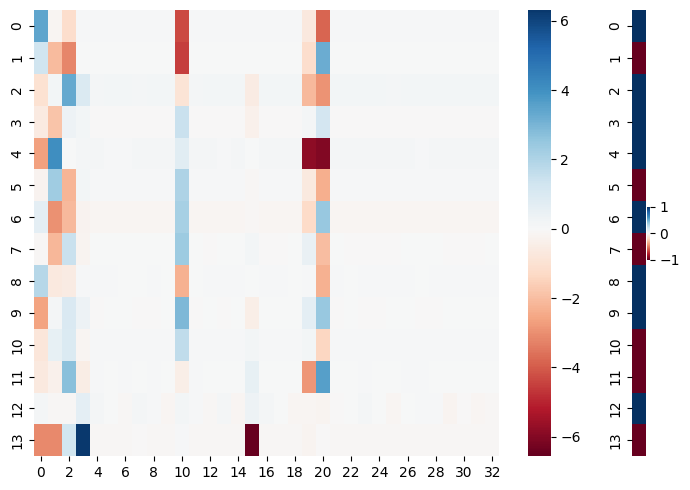

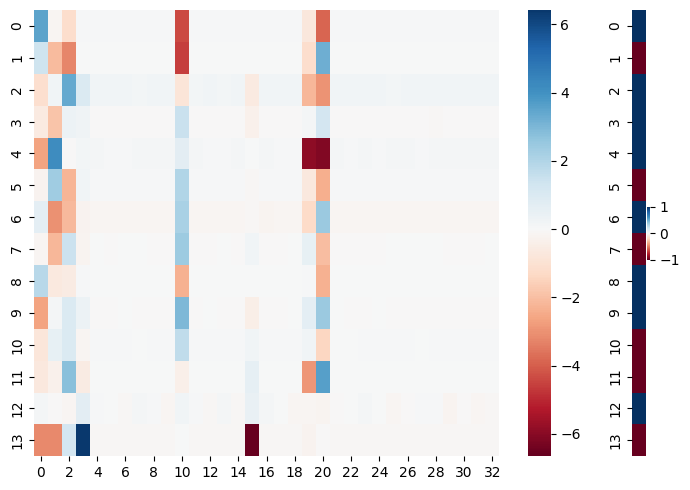

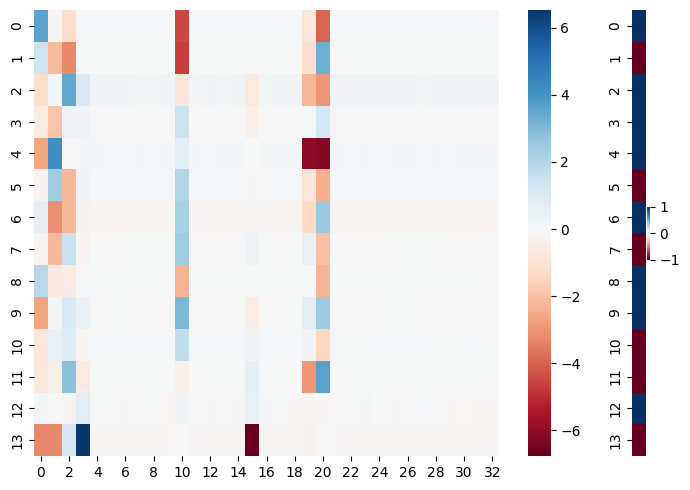

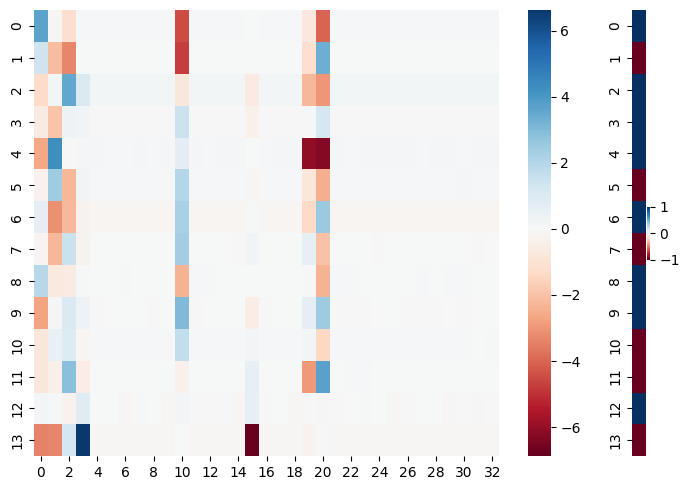

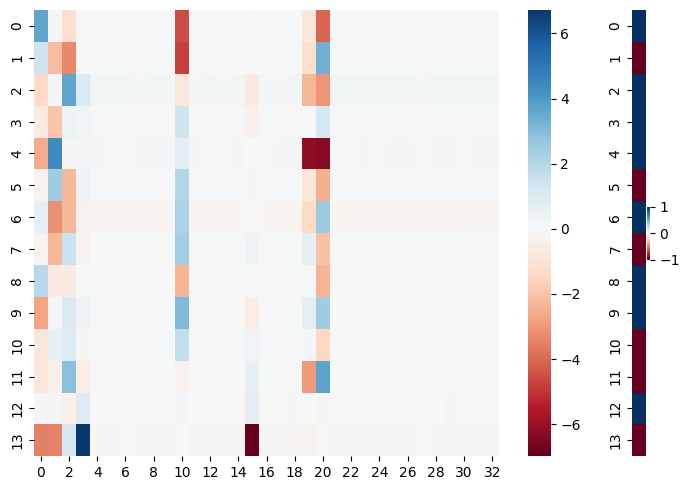

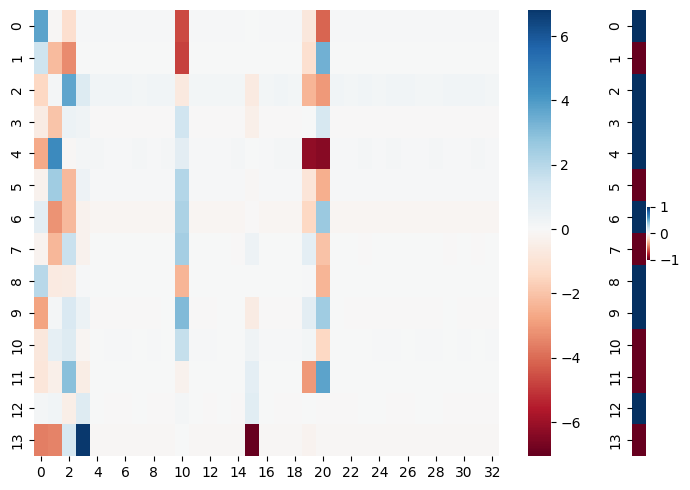

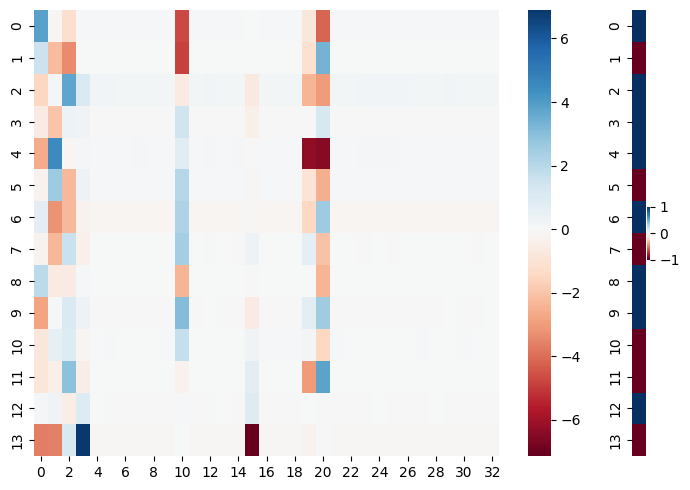

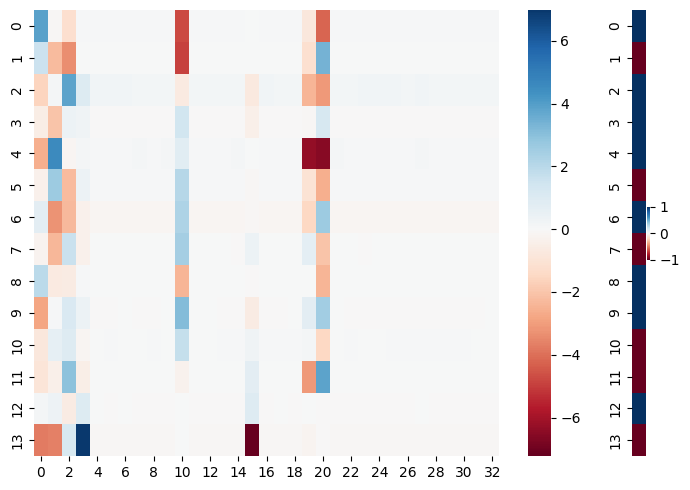

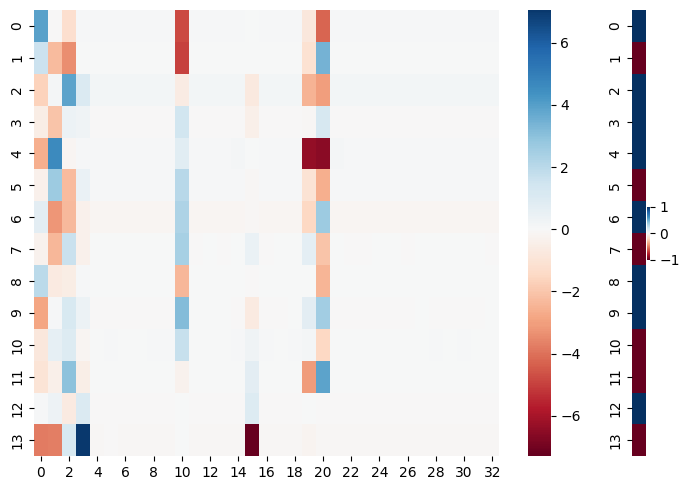

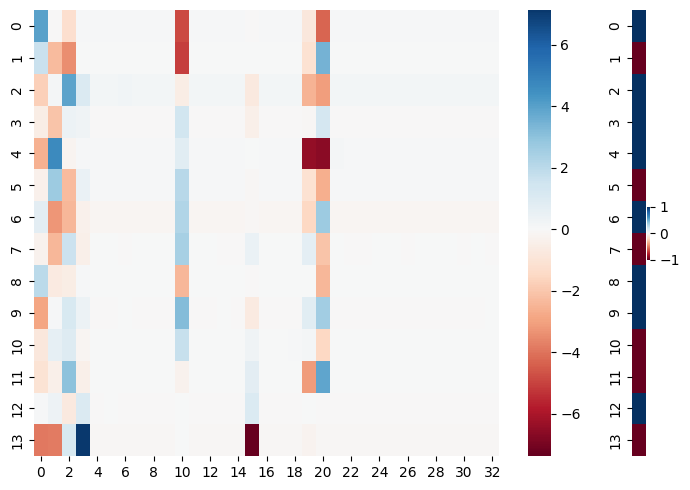

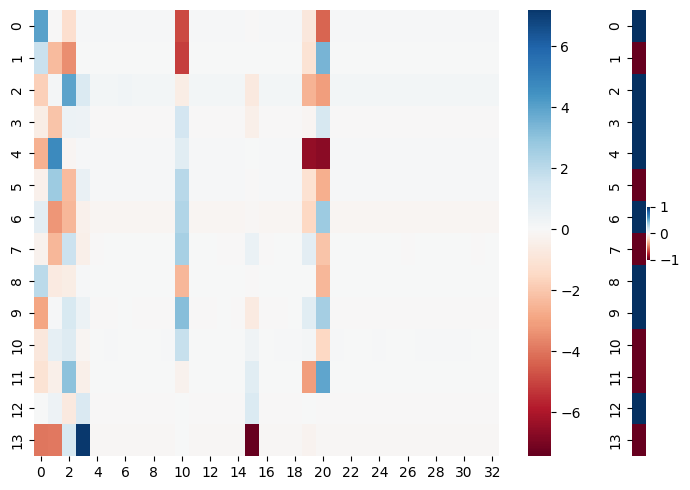

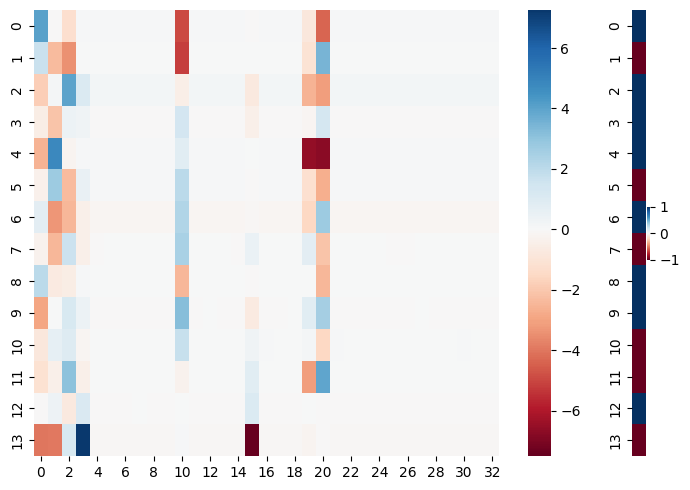

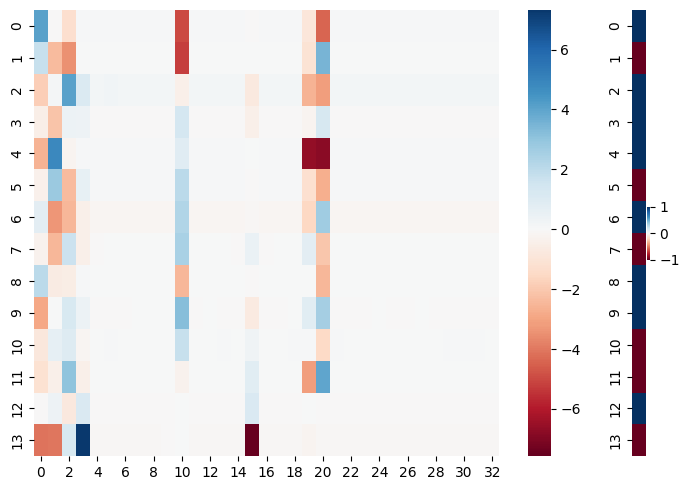

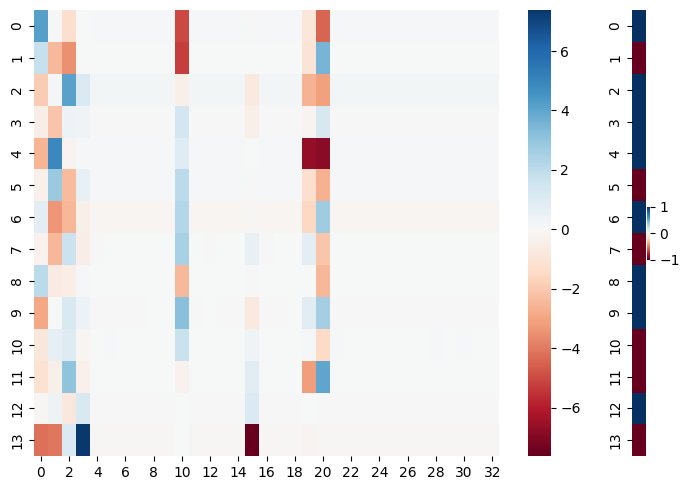

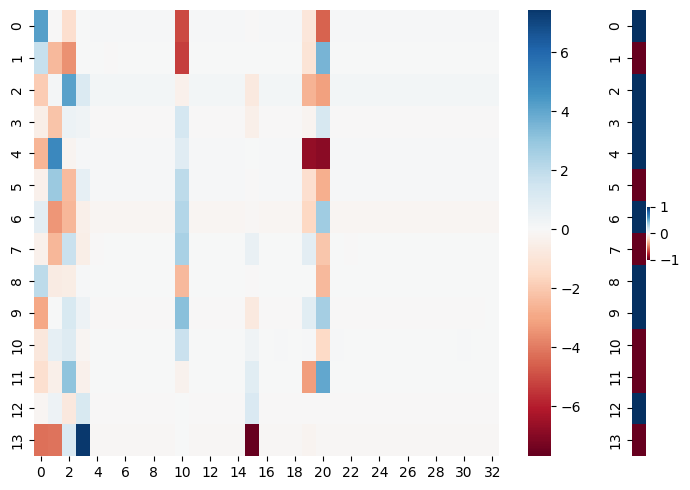

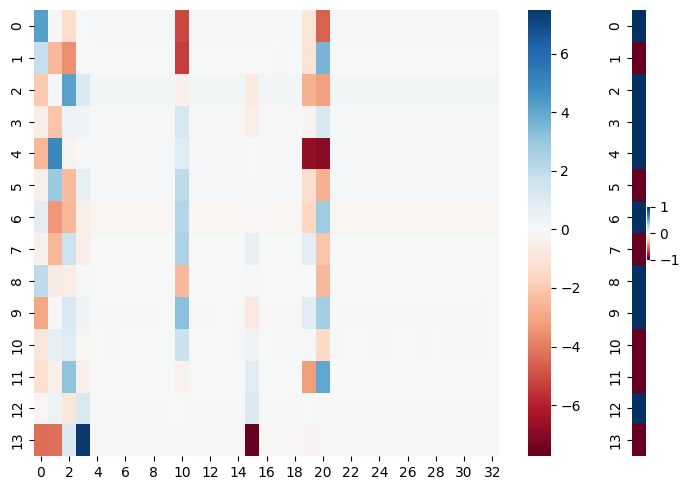

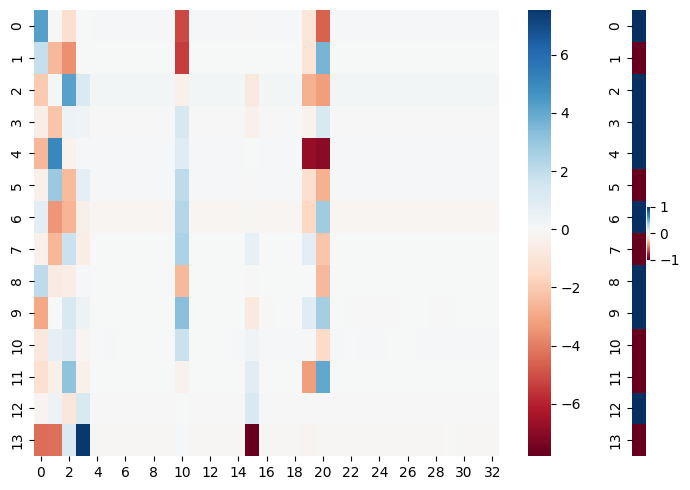

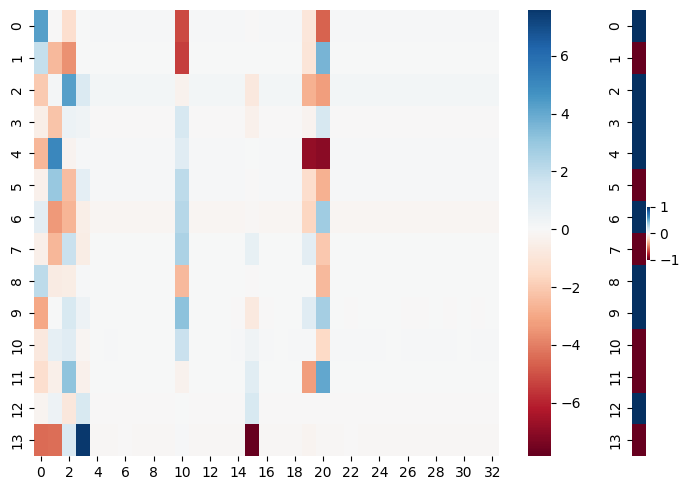

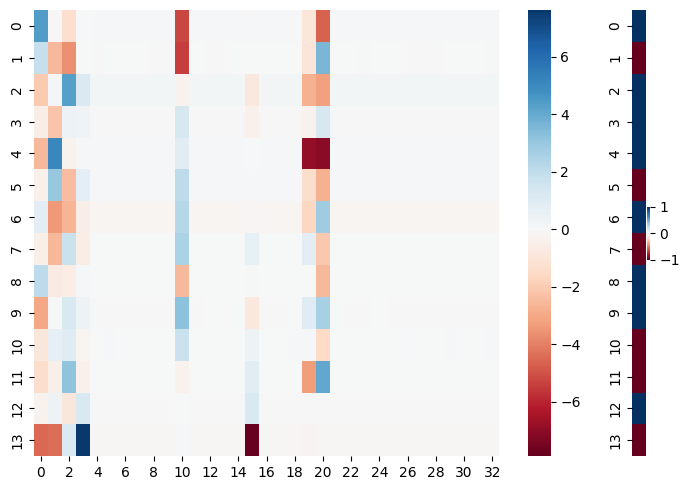

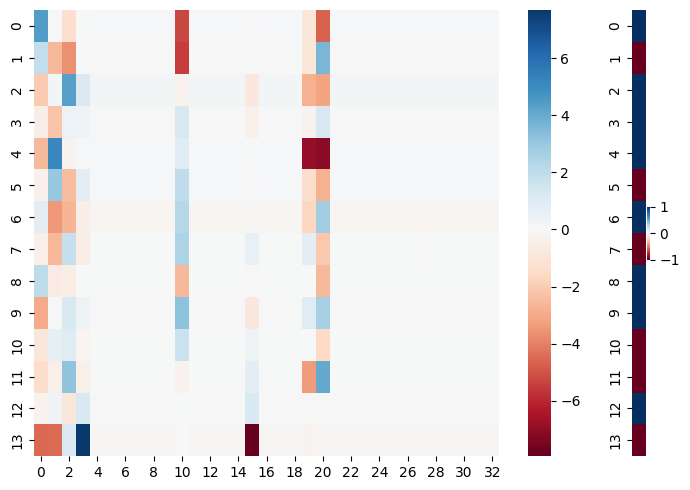

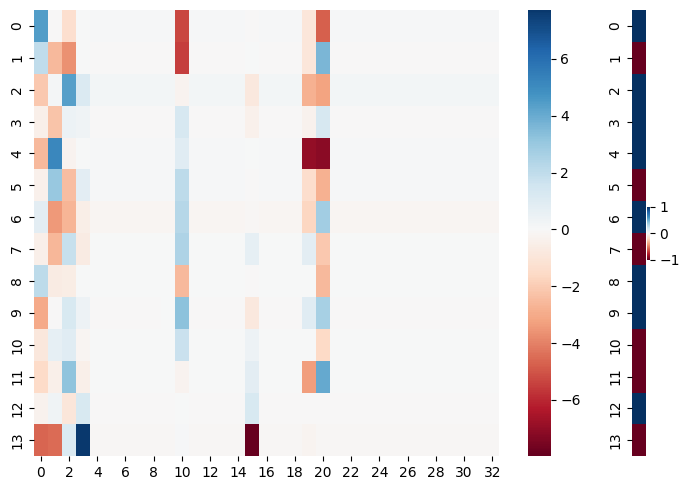

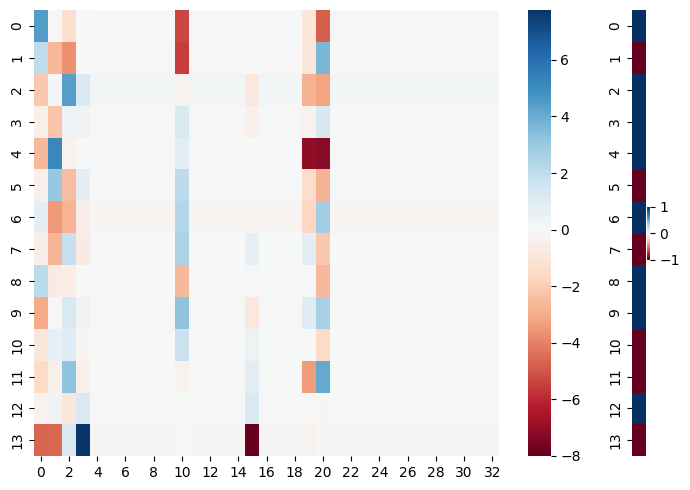

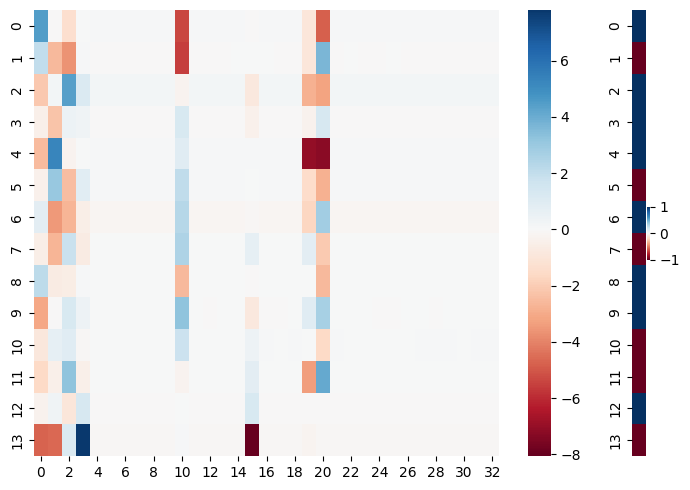

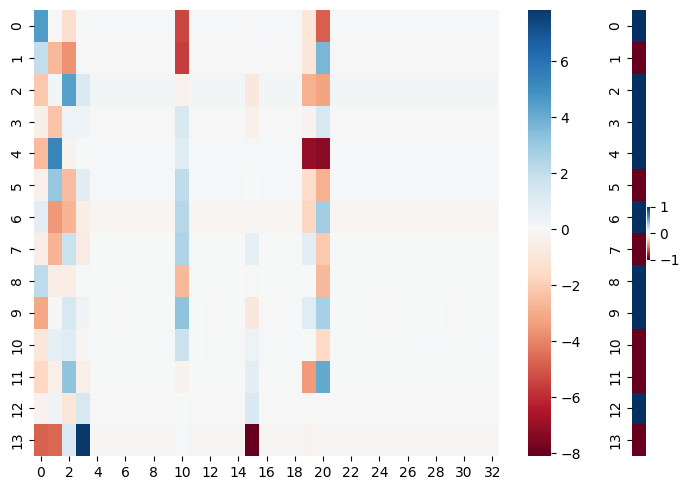

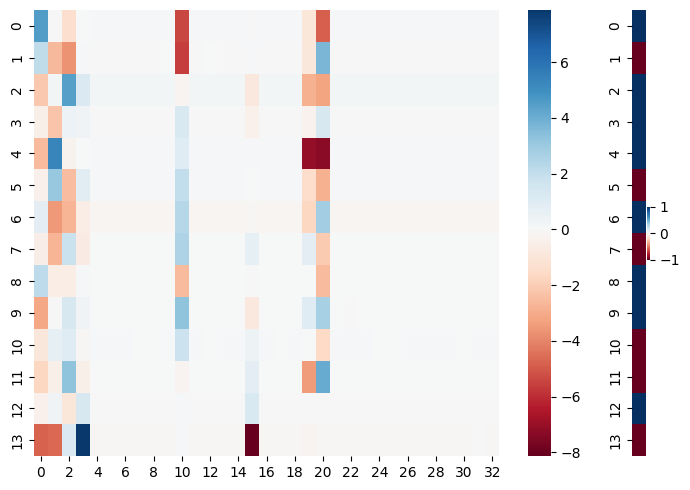

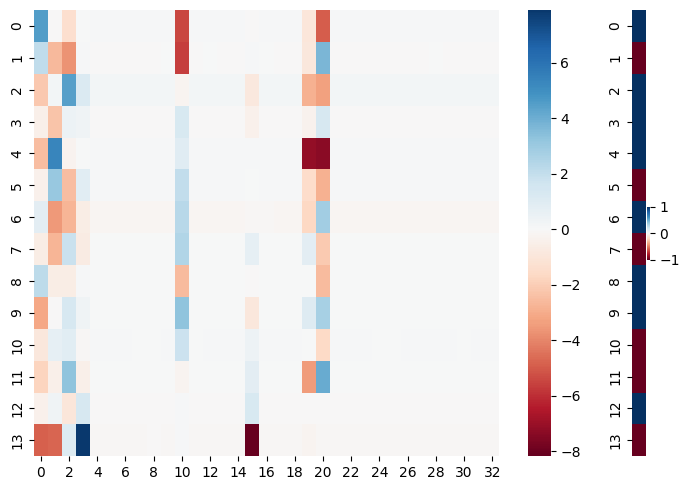

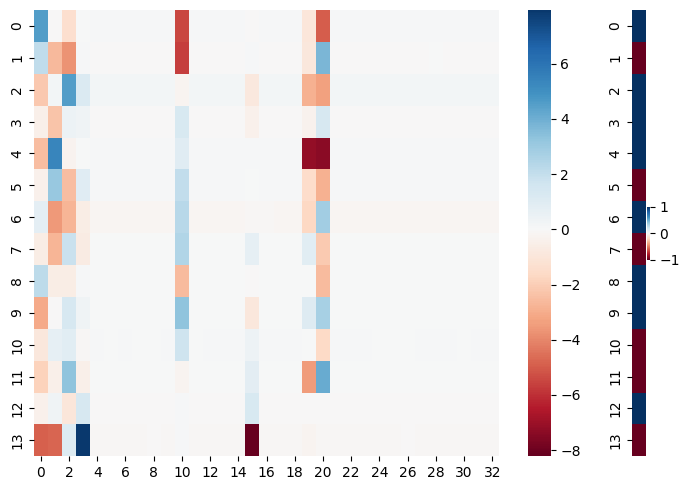

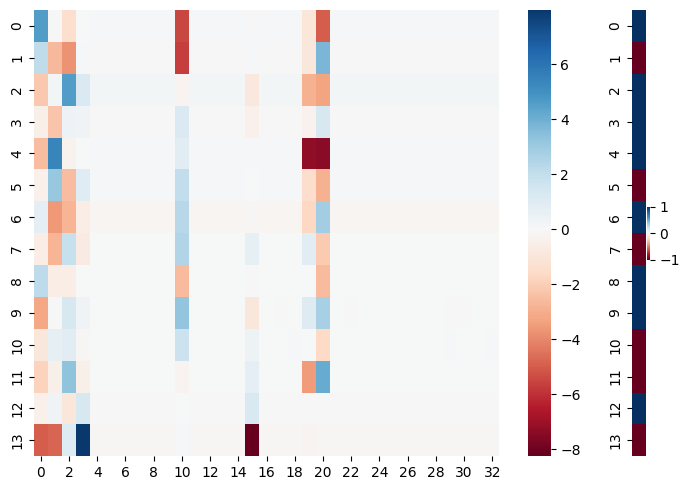

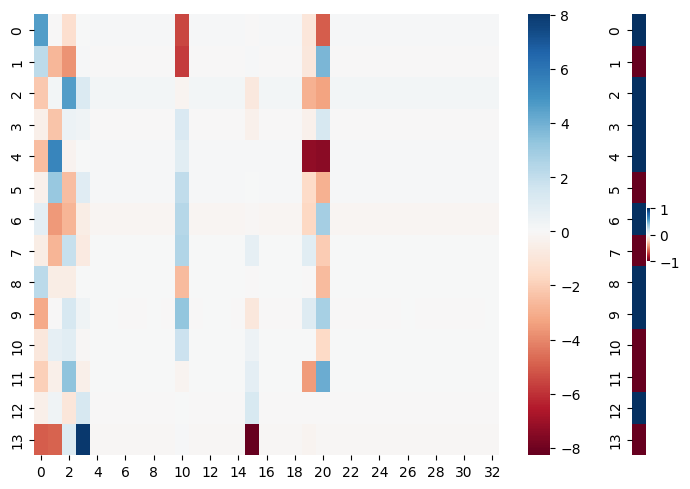

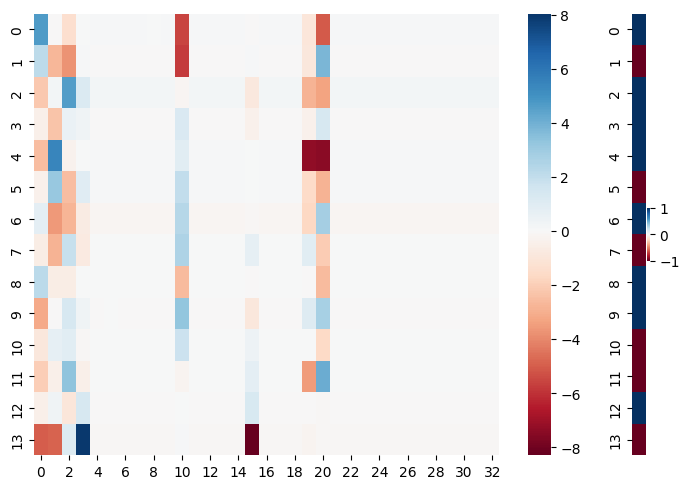

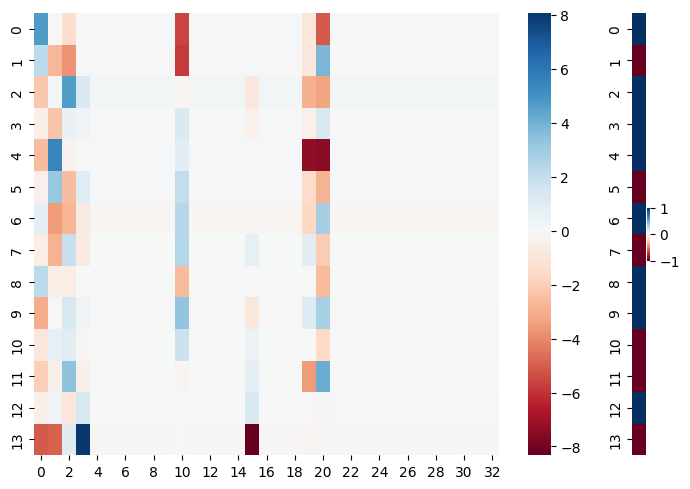

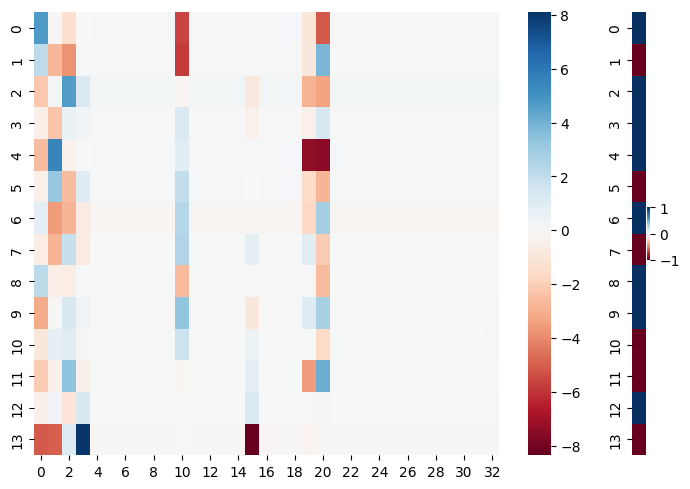

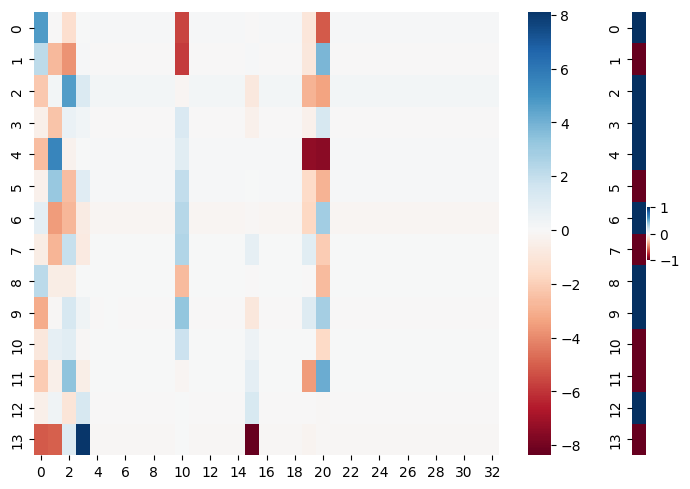

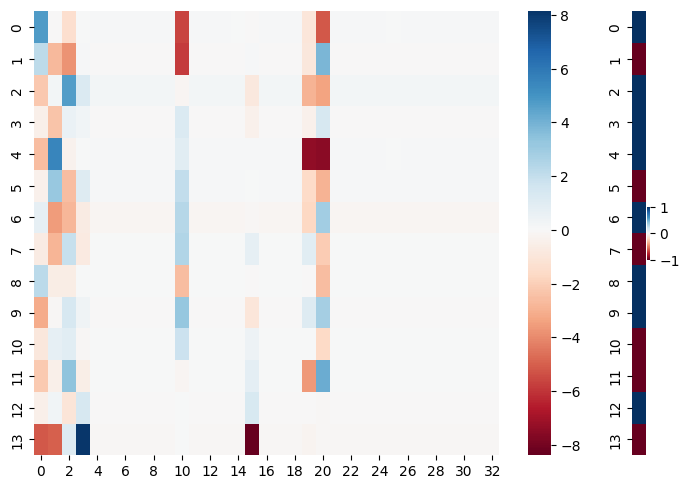

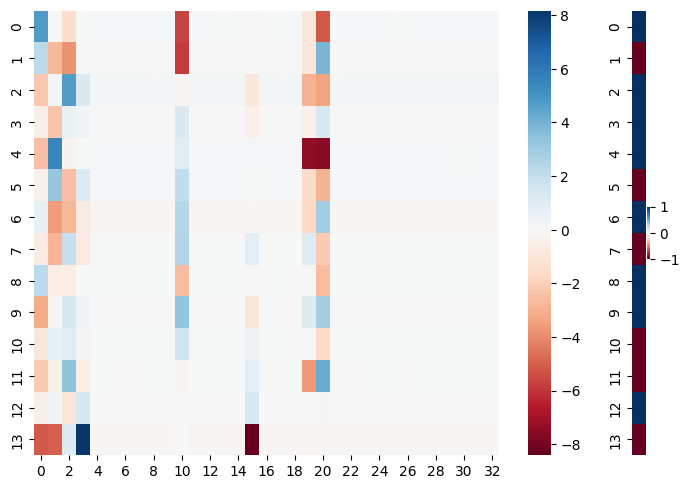

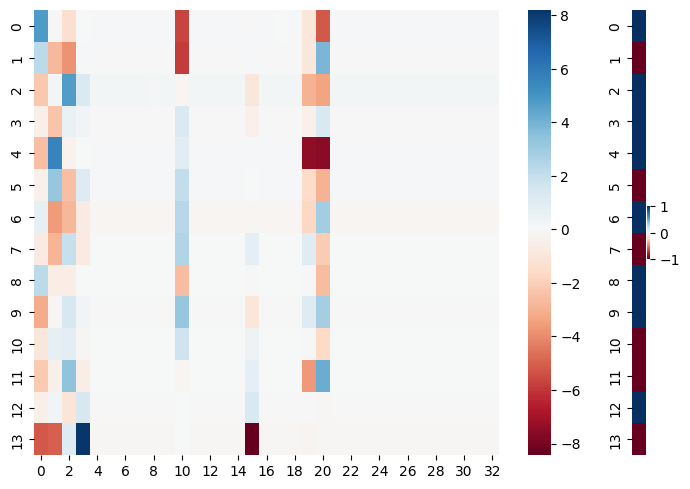

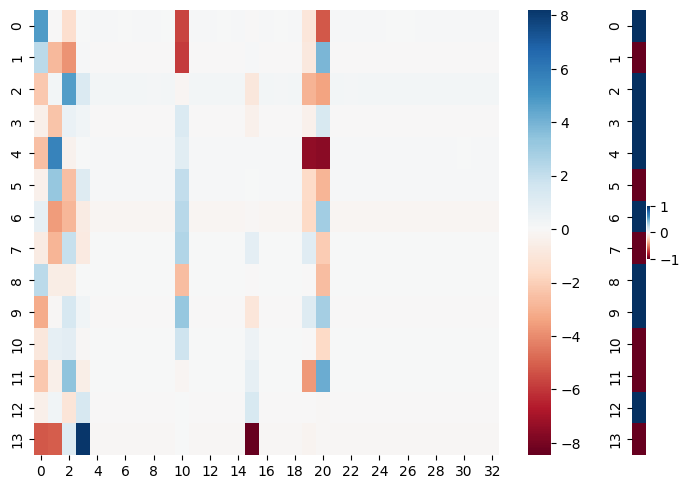

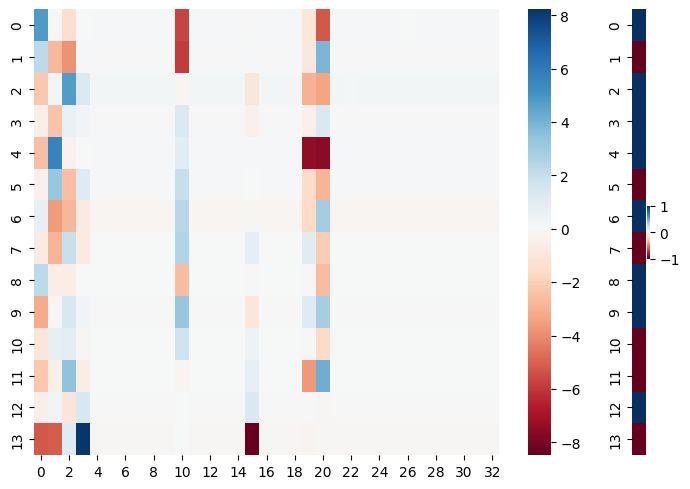

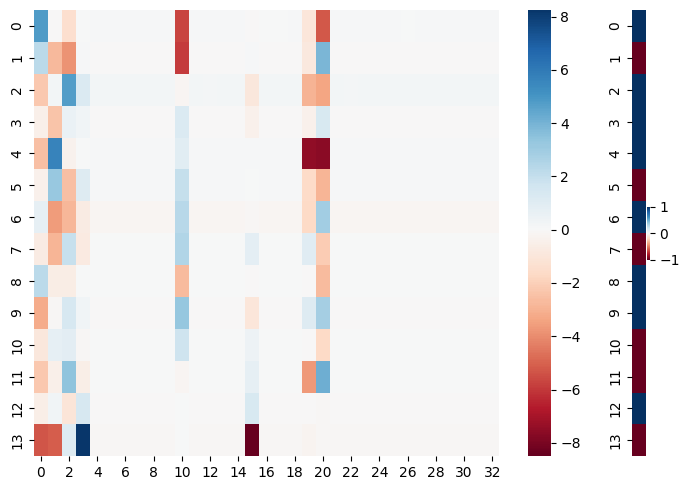

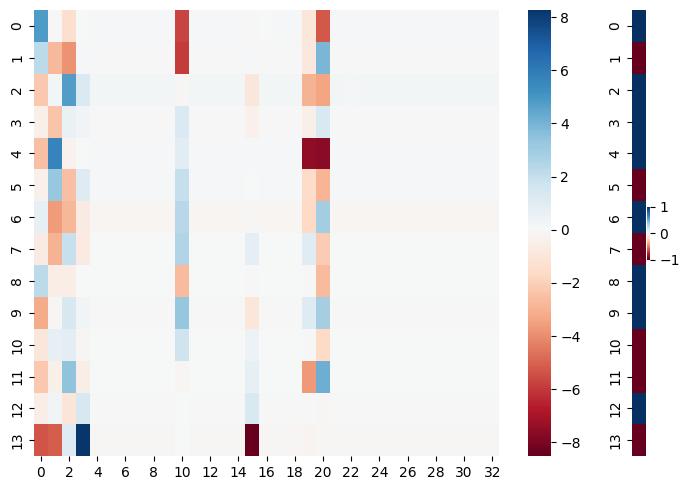

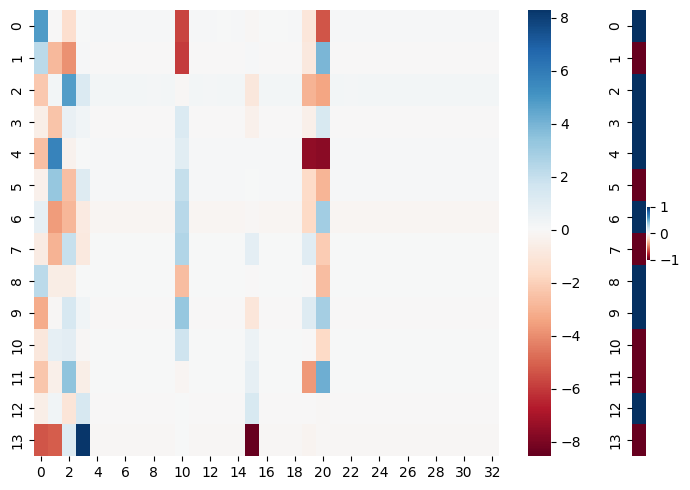

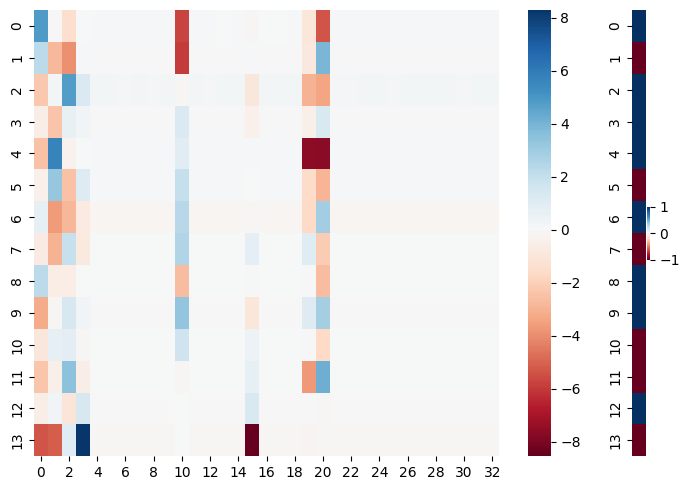

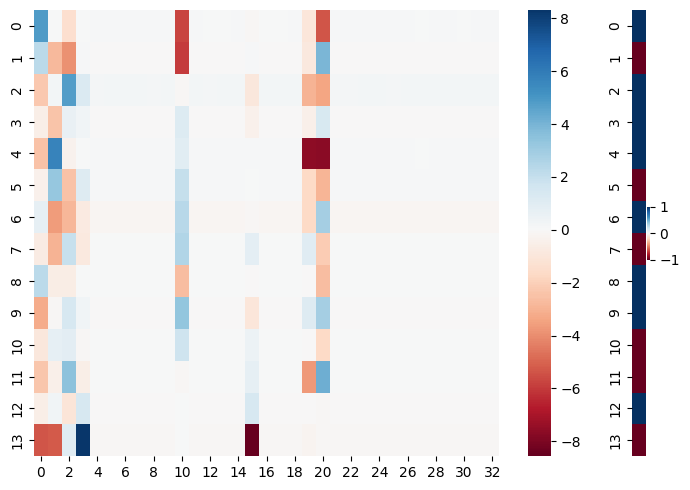

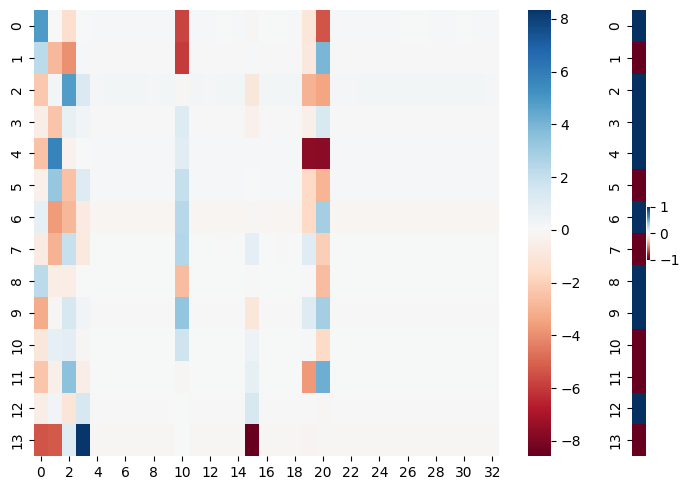

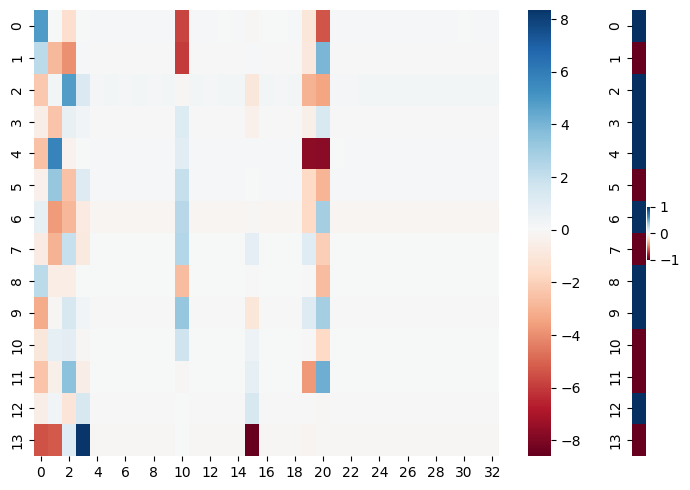

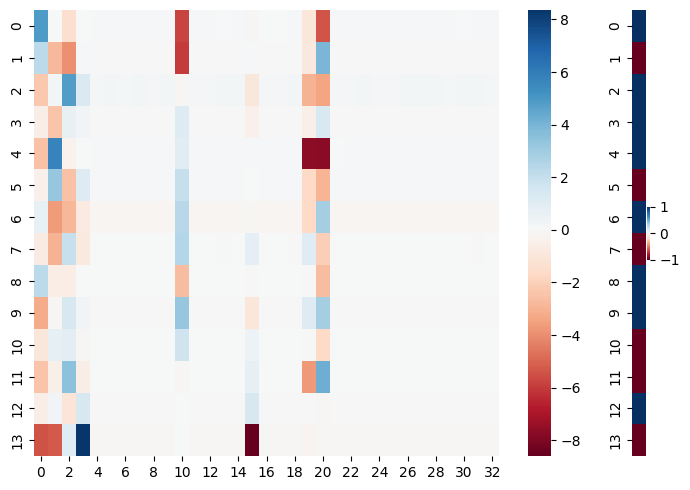

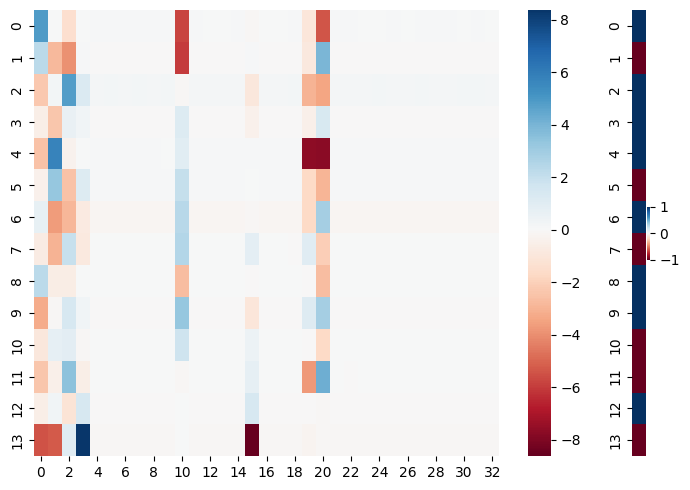

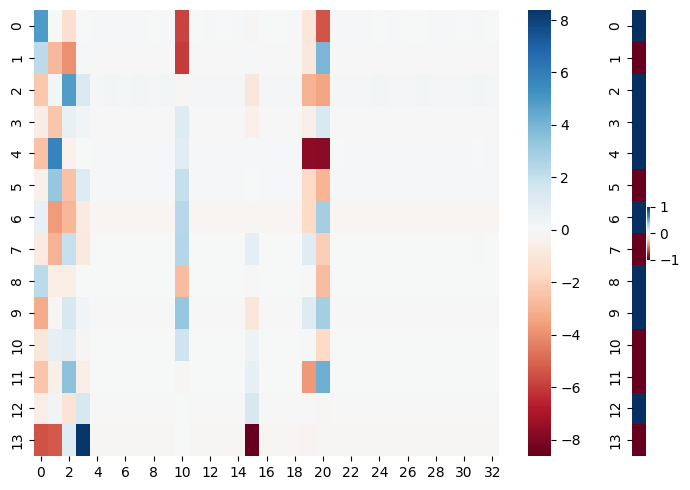

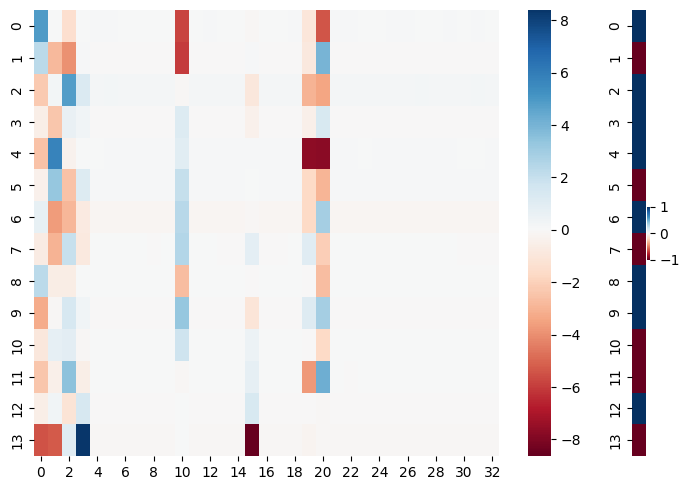

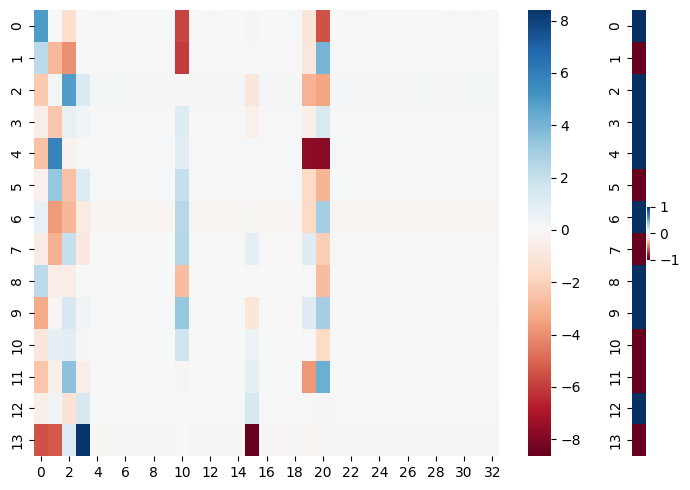

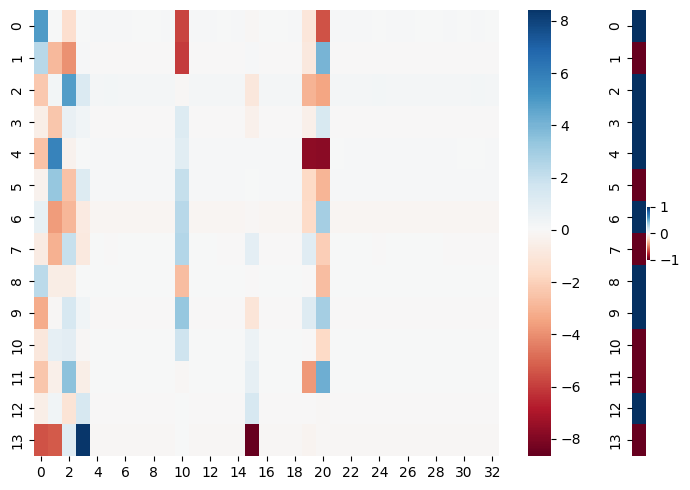

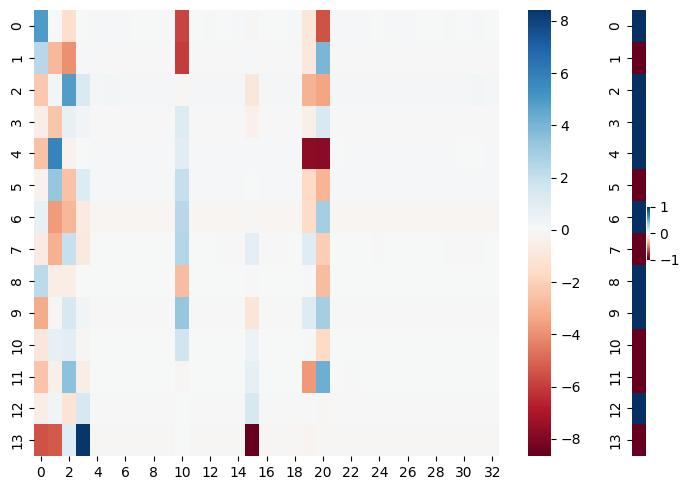

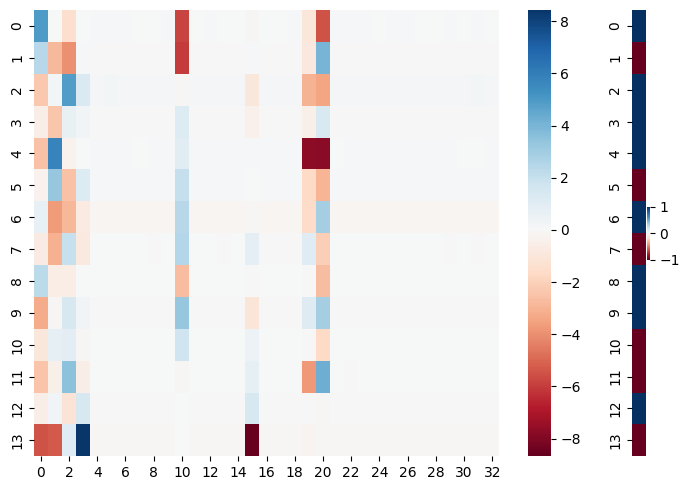

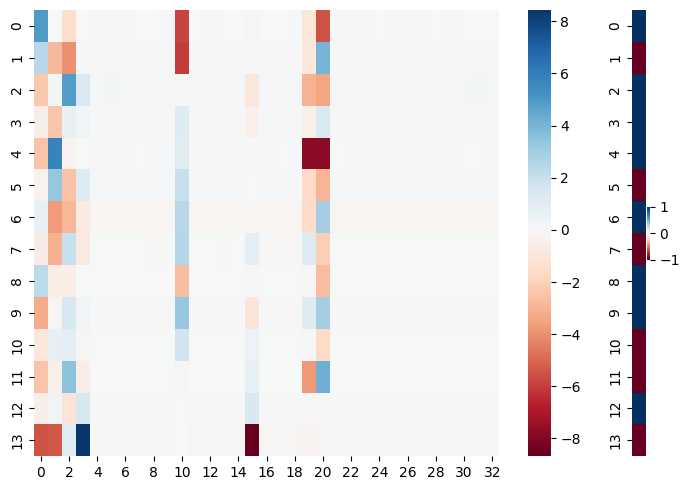

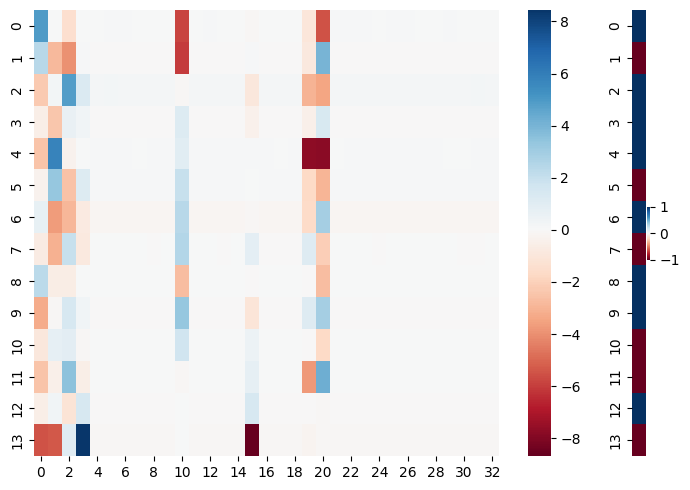

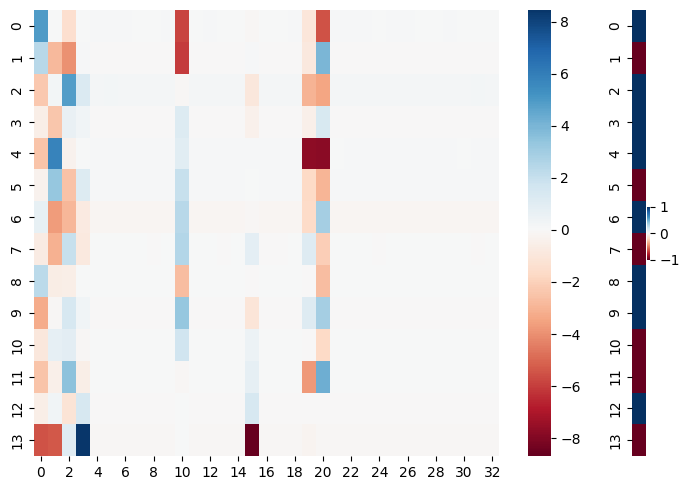

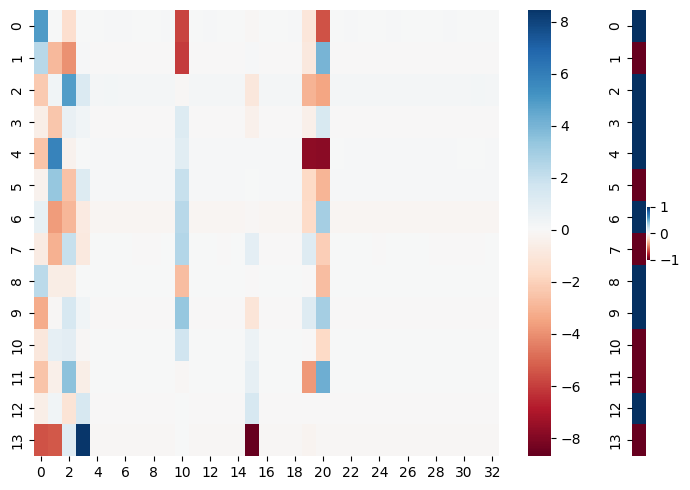

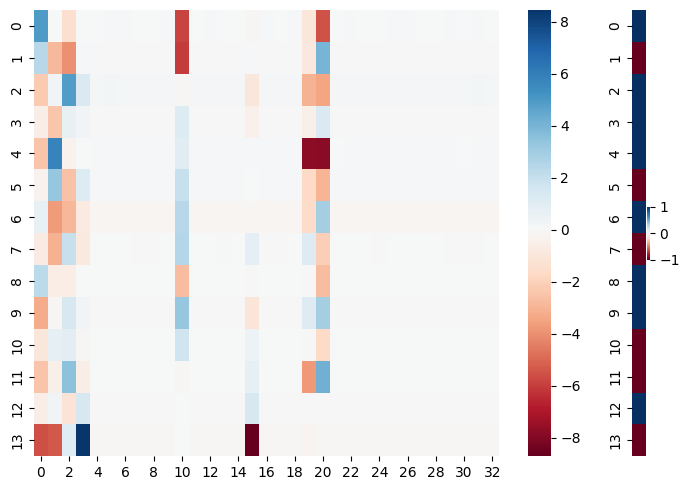

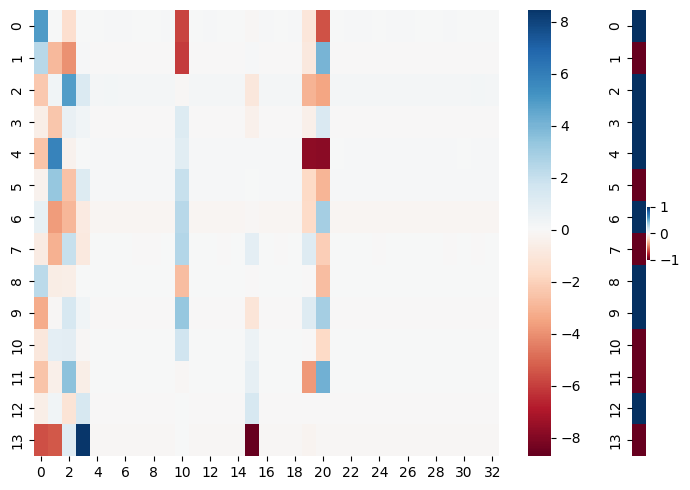

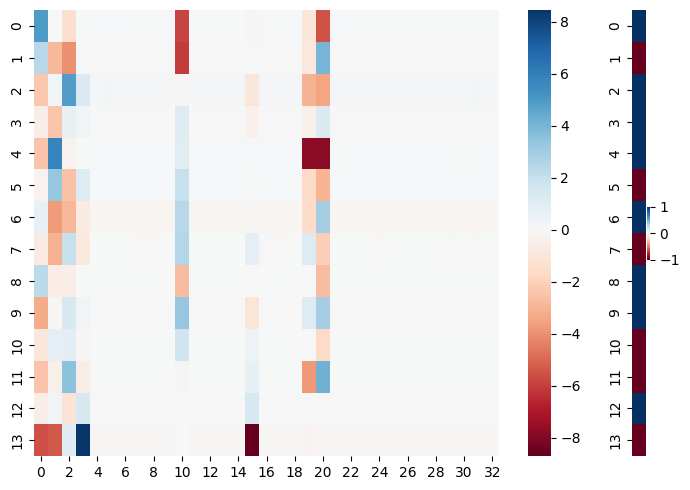

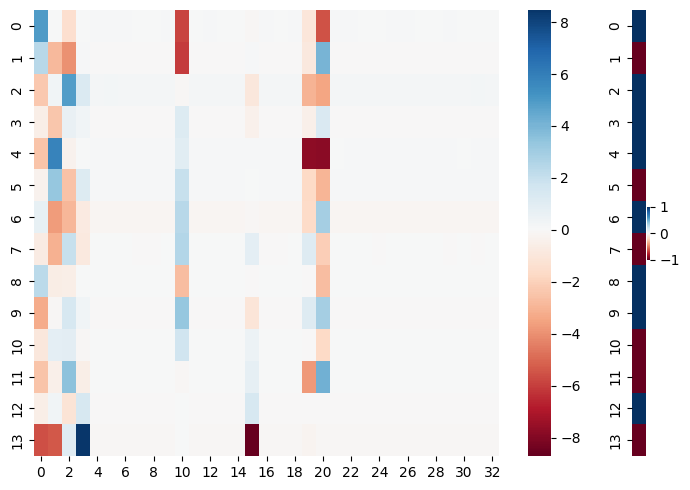

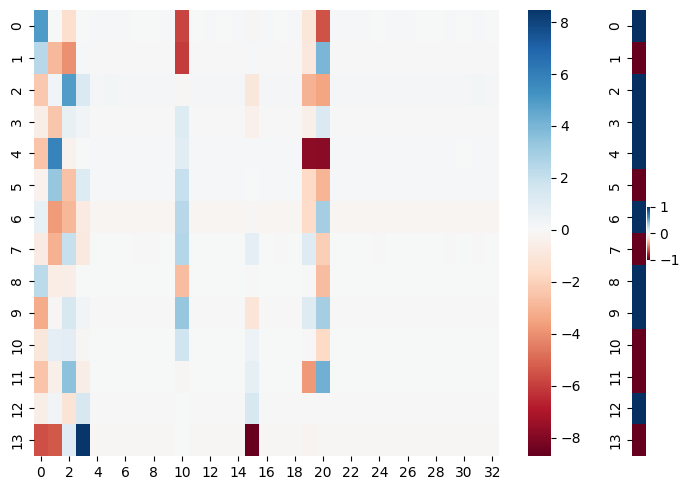

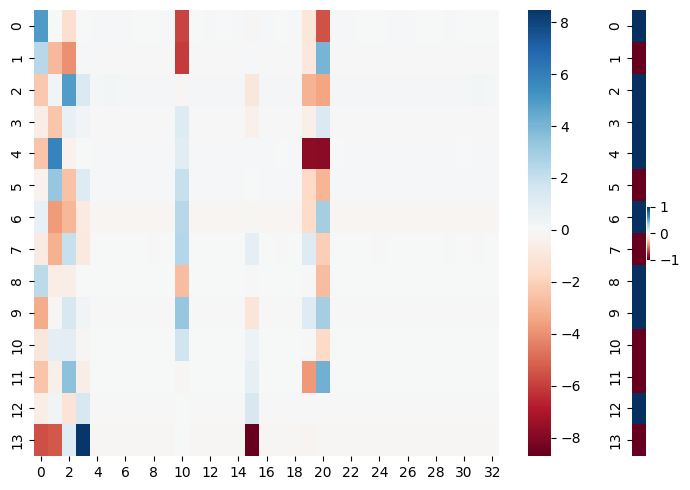

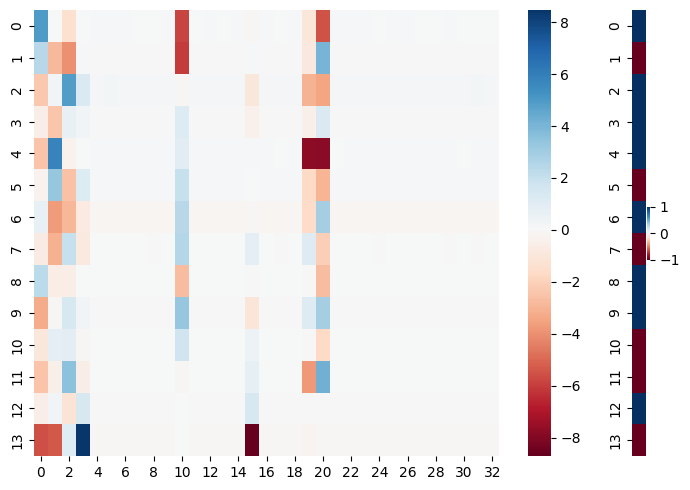

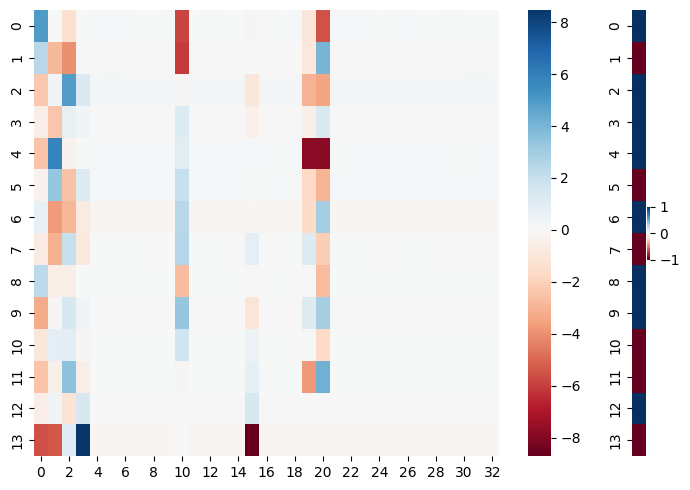

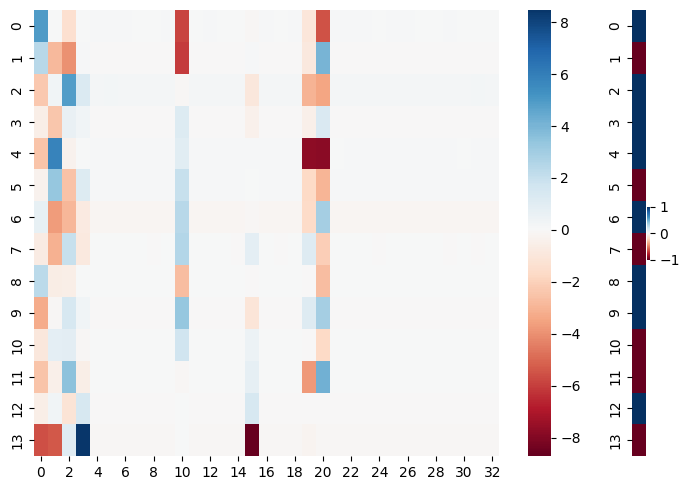

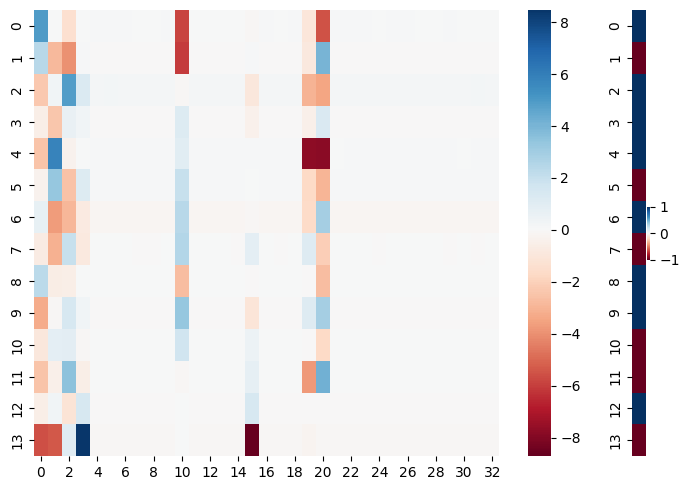

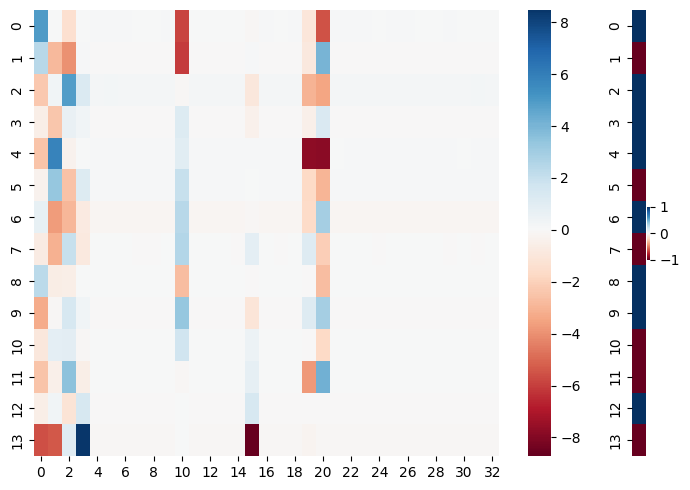

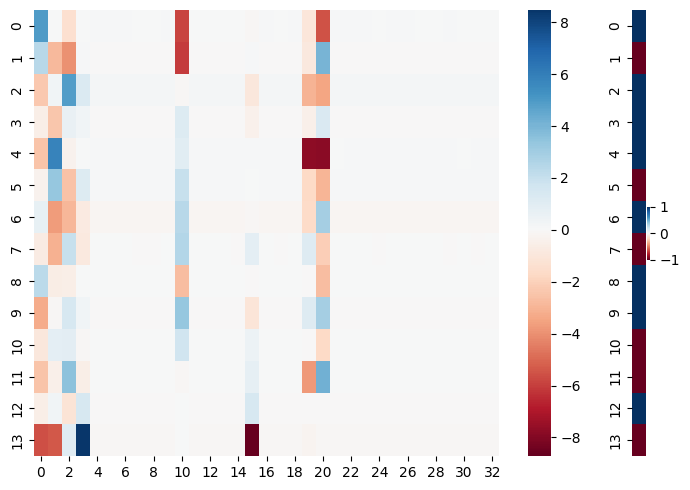

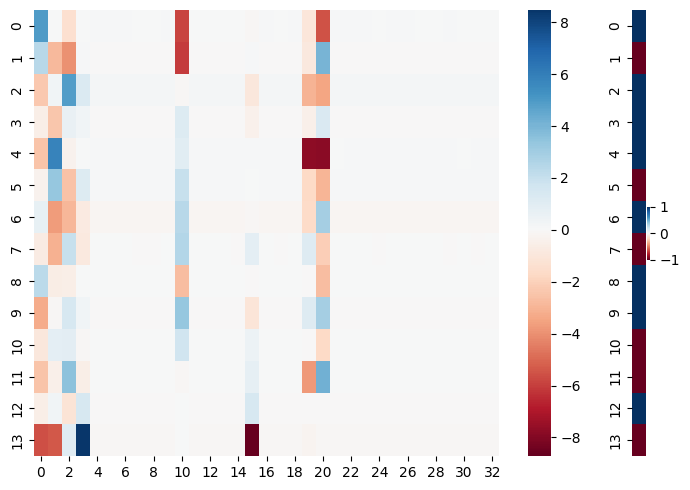

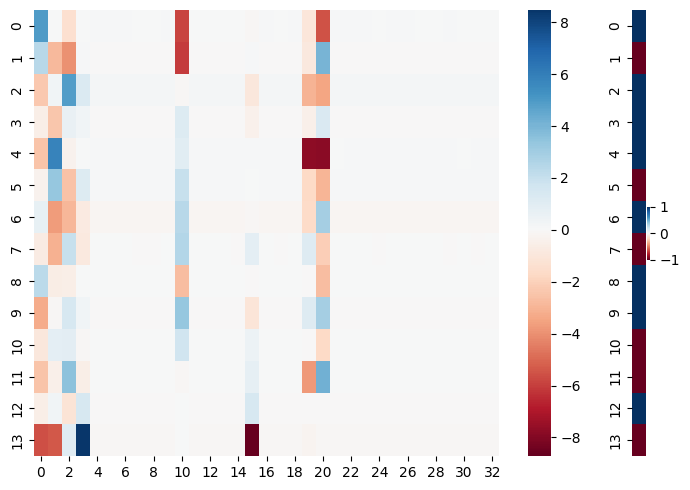

In [78]:
os.makedirs(f"./plots/mtsp_weights_over_training/v2/{config.cache_key()}", exist_ok=True)
for save_weight_step_path in save_weight_step_paths[:1000]:
    model = MultitaskSparseParityModel(
        d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
    )
    # save_weight_step_path = save_weight_step_paths[-1]
    model.load_state_dict(storer.read(save_weight_step_path + "/model"))

    n_cols_left = model.l1.weight.data[neuron_mask].shape[1]
    n_cols_right = 1

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
    )
    sns.heatmap(
        data=model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1),
        cmap="RdBu",
        center=0,
        ax=ax1,
    )
    # sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
    sns.heatmap(
        data=(l2_synth[neuron_mask].unsqueeze(1) > 0).float() * 2 - 1, cmap="RdBu", center=0, ax=ax2
    )
    plt.tight_layout()
    plt.savefig(
        f"./plots/mtsp_weights_over_training/v2/{config.cache_key()}/{save_weight_step_path}.png"
    )

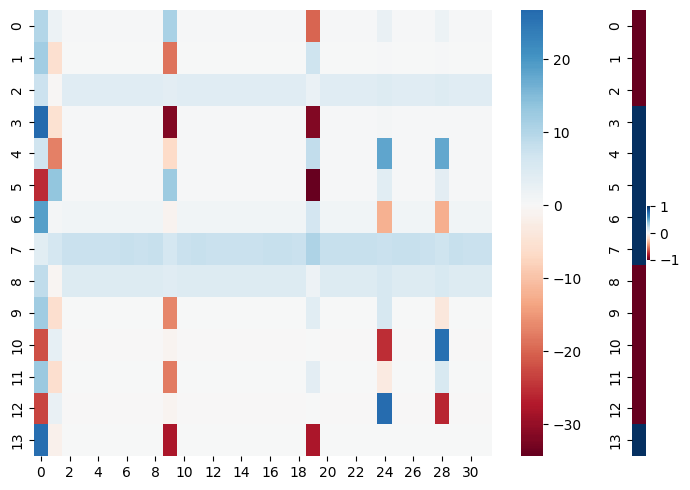

In [134]:
rows = model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1)
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>6}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:6.1f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

        col0  col1  col2  col3  col4  col5  col6  col7  col8  col9 col10 col11 col12 col13 col14 col15 col16 col17 col18 col19 col20 col21 col22 col23 col24 col25 col26 col27 col28 col29 col30 col31
row0     9.9   2.0   0.3   0.3   0.3   0.3   0.3   0.3   0.3  11.1   0.3   0.3   0.3   0.3   0.3   0.3   0.3   0.3   0.3 -19.9   0.3   0.3   0.3   0.3   2.4   0.3   0.3   0.3   2.2   0.3   0.3   0.3
row1    11.7  -5.6   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -18.8   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   7.0   0.0   0.0   0.0   0.0   0.4   0.0   0.0   0.0   0.3   0.0   0.0   0.0
row2     7.2  -0.2   4.1   4.1   4.1   4.1   4.1   4.1   4.1   3.6   4.1   4.1   4.1   4.1   4.1   4.1   4.1   4.1   4.1   2.3   4.1   4.1   4.1   4.1   4.8   4.1   4.1   4.1   4.7   4.1   4.1   4.1
row3    26.8  -5.2   0.3   0.3   0.3   0.3   0.3   0.3   0.3 -31.7   0.3   0.3   0.3   0.3   0.3   0.3   0.3   0.3   0.3 -31.5   0.3   0.3   0.3   0.3   0.7   0.3   0.3   0.3   0.5   0.3   0.3   0.3
row4 

In [ ]:
l2_synth[neuron_mask]

tensor([ 19.8971, -19.8391, -19.9002, -16.7953,  19.4866])

In [109]:
rows = l1_for_tasks[neuron_mask]
n_cols = rows[0].shape[0]
print("o7 = original idx is 7")
print(
    "      "
    + "".join(
        f"{'col' + str(j) + ' o' + str(input_idxs.reshape(-1)[j].item()):>10}"
        for j in range(n_cols)
    )
)
# print("      " + "".join(f"{'col' + str(j):>10}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:10.4f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

o7 = original idx is 7
         col0 o0   col1 o7  col2 o17   col3 o1  col4 o22  col5 o26
row0      1.7811    0.0627    0.0630    0.3556    0.0626    0.0628
row1      2.6273    0.0083    0.0081   -1.2488    0.0082    0.0076
row2      4.9977    2.8358    2.8476   -0.1634    2.8428    2.8483
row3      3.3728    0.0320    0.0319   -0.6568    0.0320    0.0320
row4      1.3262    0.0793    0.0803   -3.4202    0.0796    0.0799
row5     -3.0317    0.0400    0.0401    1.5843    0.0403    0.0404
row6      4.1549    0.2316    0.2312    0.1195    0.2317    0.2307
row7      1.5002    2.8358    2.8621    2.2340    2.8445    2.8578
row8      4.6751    2.4658    2.4944   -0.3568    2.4726    2.4873
row9      2.7632    0.0393    0.0398   -1.3544    0.0398    0.0395
row10    -2.9196   -0.0261   -0.0259    0.3905   -0.0259   -0.0258
row11     2.8855    0.0476    0.0475   -1.3515    0.0482    0.0477
row12    -3.0056   -0.0221   -0.0223    0.3332   -0.0220   -0.0221
row13     3.3810    0.0115    0.0114   

In [ ]:
rows = l1_for_task0[neuron_mask]
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>10}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:10.4f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

            col0      col1      col2
row0      1.7811    0.0619    0.0623
row1      2.6273    0.0086    0.0079
row2      4.9977    2.8452    2.8358
row3      3.3728    0.0320    0.0320
row4      1.3262    0.0806    0.0806
row5     -3.0317    0.0400    0.0401
row6      4.1549    0.2306    0.2300
row7      1.5002    2.8511    2.8387
row8      4.6751    2.4829    2.4704
row9      2.7632    0.0393    0.0397
row10    -2.9196   -0.0262   -0.0264
row11     2.8855    0.0478    0.0482
row12    -3.0056   -0.0220   -0.0220
row13     3.3810    0.0115    0.0115


In [58]:
torch.cat((torch.arange(14).unsqueeze(1), l1_for_task0[neuron_mask]), dim=1)

tensor([[ 0.0000e+00,  8.3866e-02, -3.1328e+00,  2.0389e+00,  2.9835e+00,
         -2.3993e+00],
        [ 1.0000e+00,  4.2002e+00, -1.7527e+00, -1.5990e+00, -1.7932e+00,
         -9.9495e-01],
        [ 2.0000e+00,  4.9844e-01,  1.5476e+00, -2.0613e+00, -1.5447e+00,
          1.5448e+00],
        [ 3.0000e+00, -1.1154e-06, -1.8859e+00,  2.8490e+00, -2.8490e+00,
          1.8859e+00],
        [ 4.0000e+00,  8.3469e-07, -2.7920e+00, -2.7920e+00,  2.7920e+00,
         -1.4051e+00],
        [ 5.0000e+00,  1.0732e-06, -2.7917e+00, -2.7917e+00,  2.7917e+00,
         -1.2843e+00],
        [ 6.0000e+00,  2.0458e-06, -2.8320e+00, -2.8320e+00, -1.5537e+00,
          2.8320e+00],
        [ 7.0000e+00,  5.0194e+00,  2.5694e+00,  1.7472e+00,  2.8380e+00,
         -4.6145e-01],
        [ 8.0000e+00,  6.4019e+00, -3.3952e+00, -3.5475e+00, -3.4619e+00,
         -3.6957e+00],
        [ 9.0000e+00,  4.1982e+00, -1.7615e+00, -1.5897e+00, -1.8002e+00,
         -1.0073e+00],
        [ 1.0000e+01,  5.3486e

In [52]:
torch.cat((torch.arange(14), torch.arange(2)), dim=0)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,  0,  1])

In [43]:
torch.stack

<function torch._VariableFunctionsClass.stack>

In [33]:
l1_for_task0[neuron_mask].shape

torch.Size([14, 5])

In [34]:
torch.arange(14).unsqueeze(1).shape

torch.Size([14, 1])

In [30]:
l1_for_task0[neuron_mask]

tensor([[ 8.3866e-02, -3.1328e+00,  2.0389e+00,  2.9835e+00, -2.3993e+00],
        [ 4.2002e+00, -1.7527e+00, -1.5990e+00, -1.7932e+00, -9.9495e-01],
        [ 4.9844e-01,  1.5476e+00, -2.0613e+00, -1.5447e+00,  1.5448e+00],
        [-1.1154e-06, -1.8859e+00,  2.8490e+00, -2.8490e+00,  1.8859e+00],
        [ 8.3469e-07, -2.7920e+00, -2.7920e+00,  2.7920e+00, -1.4051e+00],
        [ 1.0732e-06, -2.7917e+00, -2.7917e+00,  2.7917e+00, -1.2843e+00],
        [ 2.0458e-06, -2.8320e+00, -2.8320e+00, -1.5537e+00,  2.8320e+00],
        [ 5.0194e+00,  2.5694e+00,  1.7472e+00,  2.8380e+00, -4.6145e-01],
        [ 6.4019e+00, -3.3952e+00, -3.5475e+00, -3.4619e+00, -3.6957e+00],
        [ 4.1982e+00, -1.7615e+00, -1.5897e+00, -1.8002e+00, -1.0073e+00],
        [ 5.3486e+00,  2.6871e+00,  2.7465e+00,  3.6115e+00,  5.0791e-01],
        [ 3.2006e+00, -2.2543e-01,  5.0290e+00, -6.6949e-02,  4.0080e+00],
        [ 2.9487e+00, -3.6985e+00, -3.0416e+00,  3.2605e+00, -4.0573e+00],
        [ 4.2006e+00, -1.

In [18]:
l1_for_task0[neuron_mask]

tensor([[ 8.3866e-02, -3.1328e+00,  2.0389e+00,  2.9835e+00, -2.3993e+00],
        [ 4.2002e+00, -1.7527e+00, -1.5990e+00, -1.7932e+00, -9.9495e-01],
        [ 4.9844e-01,  1.5476e+00, -2.0613e+00, -1.5447e+00,  1.5448e+00],
        [-1.1154e-06, -1.8859e+00,  2.8490e+00, -2.8490e+00,  1.8859e+00],
        [ 8.3469e-07, -2.7920e+00, -2.7920e+00,  2.7920e+00, -1.4051e+00],
        [ 1.0732e-06, -2.7917e+00, -2.7917e+00,  2.7917e+00, -1.2843e+00],
        [ 2.0458e-06, -2.8320e+00, -2.8320e+00, -1.5537e+00,  2.8320e+00],
        [ 5.0194e+00,  2.5694e+00,  1.7472e+00,  2.8380e+00, -4.6145e-01],
        [ 6.4019e+00, -3.3952e+00, -3.5475e+00, -3.4619e+00, -3.6957e+00],
        [ 4.1982e+00, -1.7615e+00, -1.5897e+00, -1.8002e+00, -1.0073e+00],
        [ 5.3486e+00,  2.6871e+00,  2.7465e+00,  3.6115e+00,  5.0791e-01],
        [ 3.2006e+00, -2.2543e-01,  5.0290e+00, -6.6949e-02,  4.0080e+00],
        [ 2.9487e+00, -3.6985e+00, -3.0416e+00,  3.2605e+00, -4.0573e+00],
        [ 4.2006e+00, -1.

In [19]:
l2_synth[neuron_mask]

tensor([ 19.8971, -19.8391, -19.9002, -16.7953,  19.4866])

In [32]:
l1_for_task0[neuron_mask]

tensor([[ 1.0261e-09,  2.3213e+00, -2.3213e+00],
        [ 1.7584e+00, -2.2425e+00, -2.2423e+00],
        [-4.8004e-07, -2.3217e+00,  2.3217e+00],
        [-1.7475e+00,  2.1726e+00,  2.1725e+00]])

<Axes: >

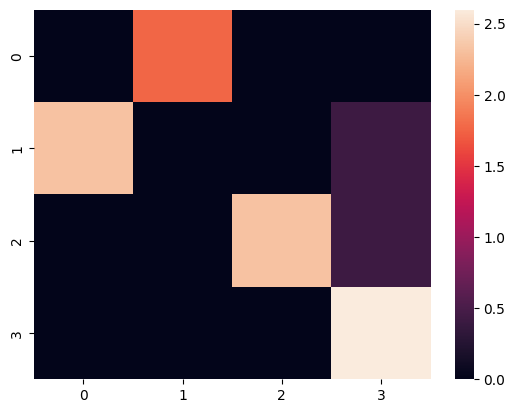

In [40]:
sns.heatmap(x3)

()

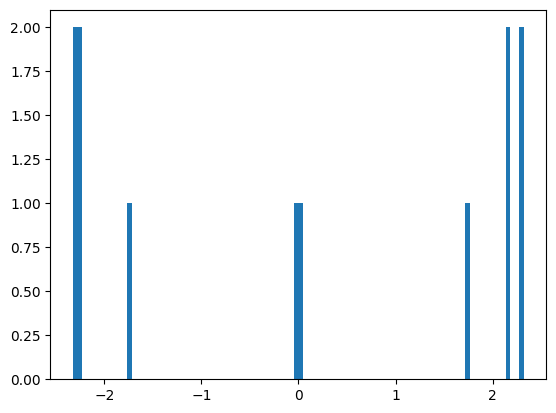

In [31]:
plt.hist(l1_for_task0[neuron_mask].reshape(-1), bins=100)
()

In [ ]:
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0)


<Axes: >

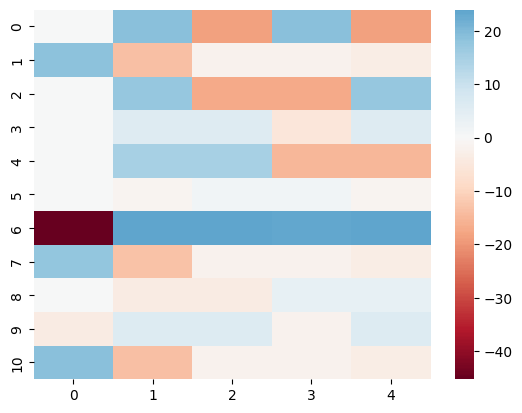

In [ ]:
sns.heatmap(
    (l1_for_task0[neuron_mask] * l2_synth[neuron_mask].unsqueeze(-1)), cmap="RdBu", center=0
)

<Axes: >

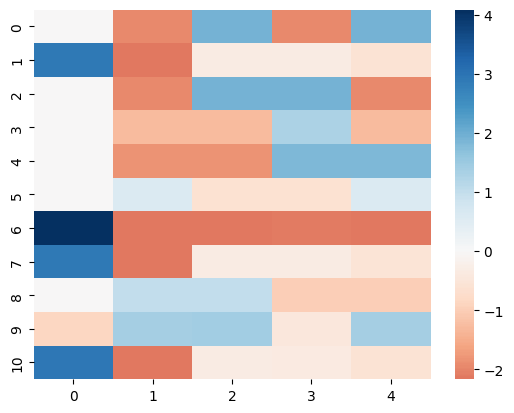

In [ ]:
sns.heatmap((l1_for_task0[neuron_mask]), cmap="RdBu", center=0)

In [36]:
l1_for_task0[neuron_mask]

tensor([[-1.7880e-07, -1.9302e+00,  1.9302e+00, -1.9302e+00,  1.9302e+00],
        [ 2.9185e+00, -2.1487e+00, -3.2018e-01, -3.3309e-01, -5.6146e-01],
        [-4.3435e-07, -1.9284e+00,  1.9284e+00,  1.9284e+00, -1.9284e+00],
        [-5.9614e-08, -1.2804e+00, -1.2804e+00,  1.2804e+00, -1.2804e+00],
        [-5.4794e-07, -1.8301e+00, -1.8301e+00,  1.8301e+00,  1.8301e+00],
        [-3.0522e-08,  6.1450e-01, -6.1450e-01, -6.1450e-01,  6.1450e-01],
        [ 4.0840e+00, -2.1572e+00, -2.1607e+00, -2.1128e+00, -2.1602e+00],
        [ 2.8912e+00, -2.1276e+00, -3.1572e-01, -3.2806e-01, -5.5536e-01],
        [-3.0726e-08,  9.8395e-01,  9.8395e-01, -9.8395e-01, -9.8395e-01],
        [-8.6947e-01,  1.3813e+00,  1.4193e+00, -4.6507e-01,  1.3817e+00],
        [ 2.9440e+00, -2.1690e+00, -3.2436e-01, -3.3788e-01, -5.6711e-01]])

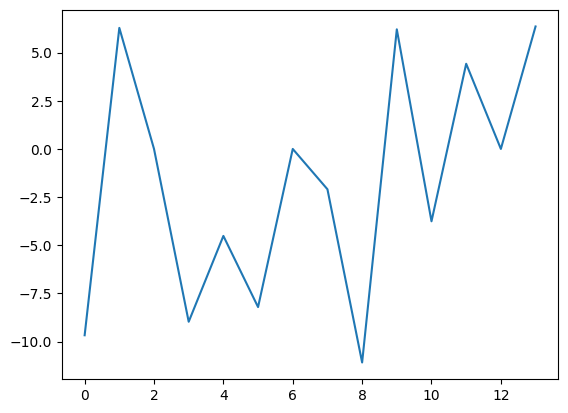

In [15]:
plt.plot(l2_synth)

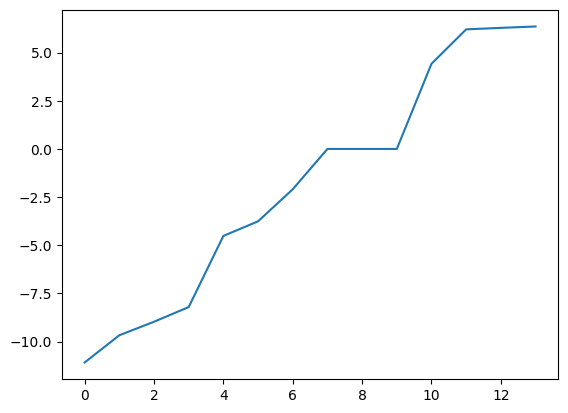

In [16]:
plt.plot(l2_synth[l2_synth.sort().indices])

In [17]:
dataset.selected_bits_by_task + 1

tensor([[24,  8, 10,  2]])

In [18]:
# sns.heatmap(model.l1.weight.data[l2_synth.sort().indices])

<Axes: >

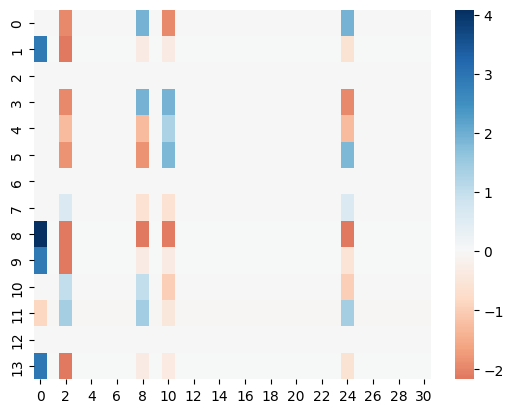

In [19]:
sns.heatmap(model.l1.weight.data, cmap="RdBu", center=0)

<Axes: >

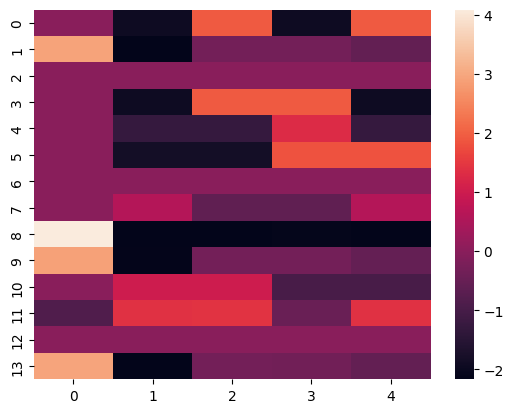

In [20]:
sns.heatmap(
    model.l1.weight.data[
        :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
    ]
)

In [21]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [22]:
F.relu(input=(torch.tensor([1, 0, 0, 0, 0]).float() @ l1_for_task0.T)) @ l2_synth

tensor(9.7345)

In [23]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0.T
x3 = F.relu(x2)
x4 = x3 @ l2_synth
x4

tensor([  9.7345,  -9.5743,  -9.5825,   9.6160, -11.2264,   8.4343,   8.4721,
        -12.3207,  -9.6165,   9.7221,   9.5887,  -9.0078,   8.3091,  -9.9947,
        -12.3969,  12.5898])

In [24]:
F.relu(l1_for_task0[:, 0]) @ l2_synth

tensor(9.7345)

<Axes: >

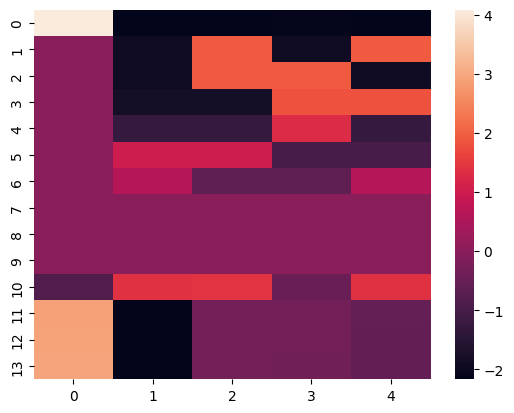

In [25]:
sns.heatmap(l1_for_task0[l2_synth.sort().indices])

In [26]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum()

tensor(3)

<Axes: >

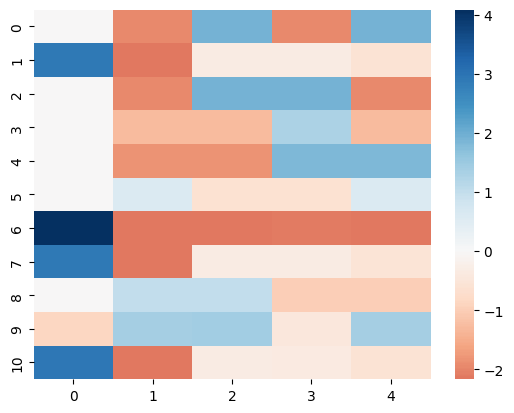

In [16]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

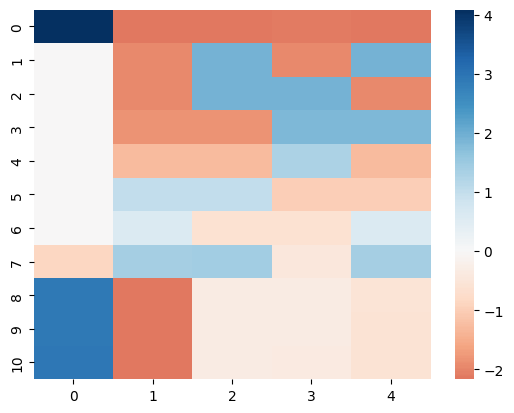

In [17]:
sns.heatmap(l1_for_task0[neuron_mask][l2_synth[neuron_mask].sort().indices], cmap="RdBu", center=0)

In [19]:
l2_synth[neuron_mask].sort().indices

tensor([4, 3, 2, 0, 6, 5, 1, 7])

In [20]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

()

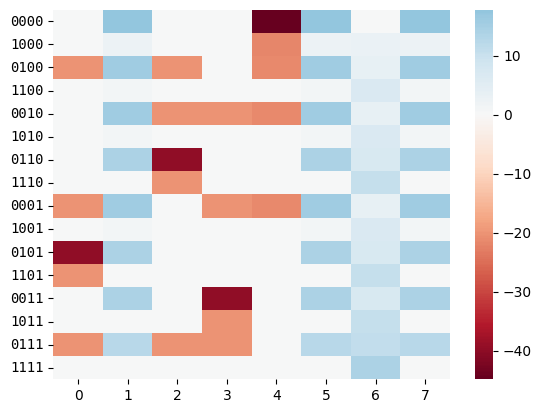

In [21]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

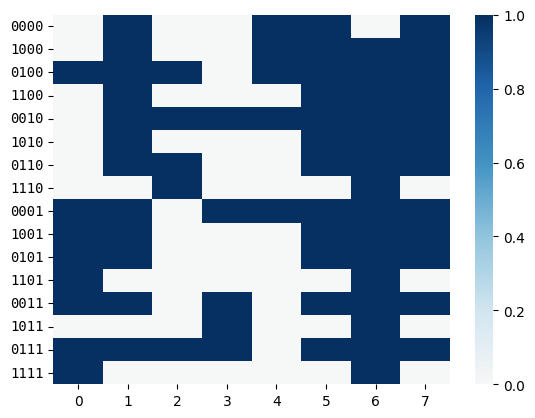

In [22]:
ax = sns.heatmap(x2 >= 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [235]:
l2_synth[neuron_mask]

tensor([ 5.6304, -1.7026, -8.3918, -3.9007, -4.8538, -7.6129, -7.7657,  1.5806,
         5.3819,  7.7784,  8.7952])

In [23]:
for x in l1_for_task0[neuron_mask][:, 0] / 3.40333 * 16 * 6:
    print(f"{x:.6f}", end=" ")

-0.000004 80.107346 -0.000005 -0.000002 113.371536 79.976242 -1.604484 80.198395 

<Axes: >

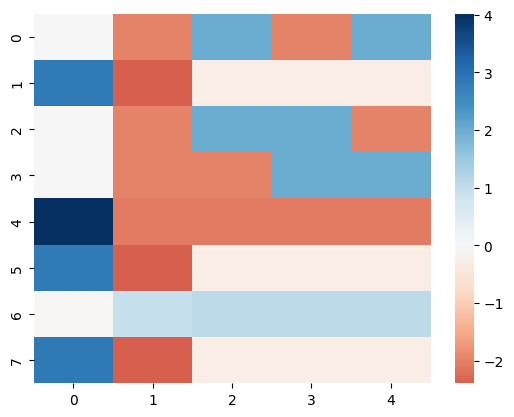

In [24]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

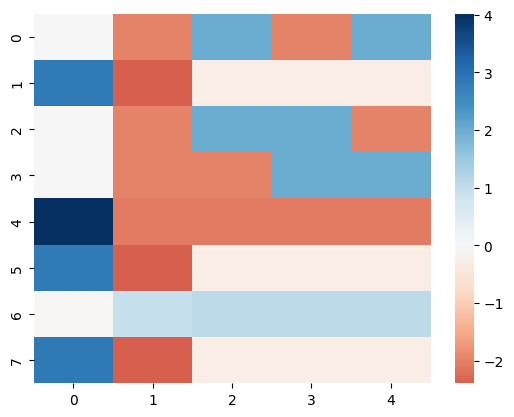

In [25]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

()

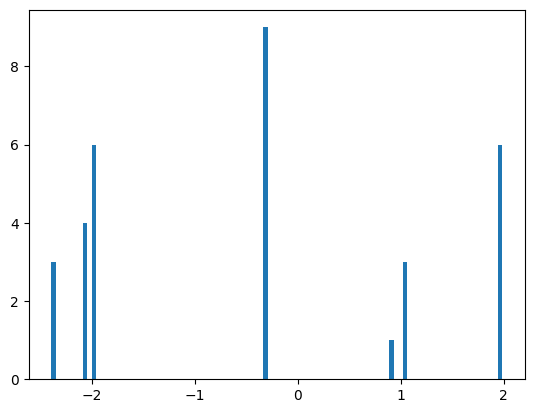

In [26]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)
()

In [30]:
(x3 * l2_synth[neuron_mask])

tensor([[ -0.0000,  17.7303,  -0.0000,  -0.0000, -44.8650,  17.6646,   0.0000,
          17.7757],
        [ -0.0000,   2.8015,  -0.0000,  -0.0000, -21.6966,   2.7926,   3.0076,
           2.8075],
        [-19.9370,  15.8910, -19.9364,  -0.0000, -21.5745,  15.8332,   3.5161,
          15.9309],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9613,   6.7223,
           0.9627],
        [ -0.0000,  15.8909, -19.9364, -19.9366, -21.5745,  15.8332,   3.5162,
          15.9308],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7225,
           0.9626],
        [ -0.0000,  14.0516, -39.8728,  -0.0000,  -0.0000,  14.0018,   7.2310,
          14.0860],
        [ -0.0000,   0.0000, -19.9364,  -0.0000,  -0.0000,   0.0000,  10.4372,
           0.0000],
        [-19.9370,  15.8909,  -0.0000, -19.9366, -21.5746,  15.8332,   3.5165,
          15.9308],
        [ -0.0000,   0.9621,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7228,
           0.9626],
        [-

()

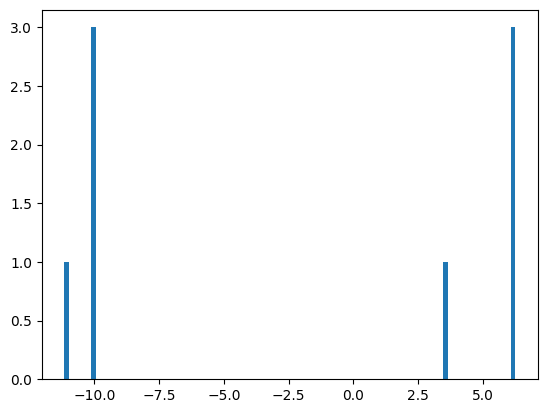

In [31]:
# plt.hist((l2_synth[neuron_mask].reshape(-1) - 1.6)/4.1, bins=100)
plt.hist((l2_synth[neuron_mask].reshape(-1)), bins=100)
()

In [32]:
(x3 * l2_synth[neuron_mask]).sum(-1)

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

In [33]:
logits = (x3 * l2_synth[neuron_mask]).sum(-1)
target = bits.sum(-1) % 2
F.binary_cross_entropy_with_logits(
    -logits, target.float()
)  # .float() as binary_cross_entropy_with_logits supports soft targets

tensor(6.5071e-05)

<Axes: >

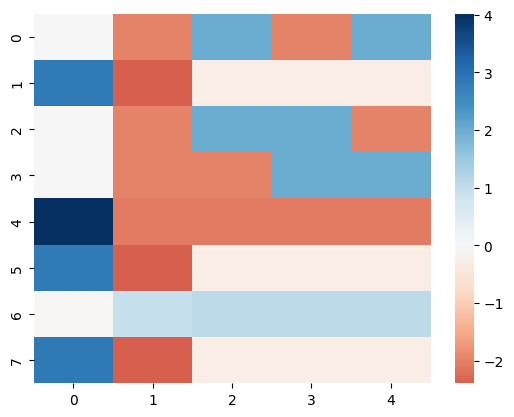

In [34]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

In [35]:
l1_for_task0[neuron_mask][:, 1:].shape

torch.Size([8, 4])

(array([3., 0., 0., 0., 0., 0., 0., 4., 0., 6., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 9., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 3., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]),
 array([-2.39409256, -2.35031962, -2.30654669, -2.26277375, -2.21900105,
        -2.17522812, -2.13145518, -2.08768225, -2.04390931, -2.00013638,
        -1.95636356, -1.91259062, -1.86881781, -1.82504487, -1.78127193,
        -1.737499  , -1.69372606, -1.64995325, -1.60618031, -1.56240749,
        -1.51863456, -1.47486162, -1.43108869, -1.38731575, -1.34354293,
        -1.29977   , -1.25599706, -1.21222425, -1.16845131, -1.12467837,
        -1.08090544, -1.03713262, -0.99335968, -0.94958675, -0.90581393,
        -0.862041  , -0.81826806, -0.77

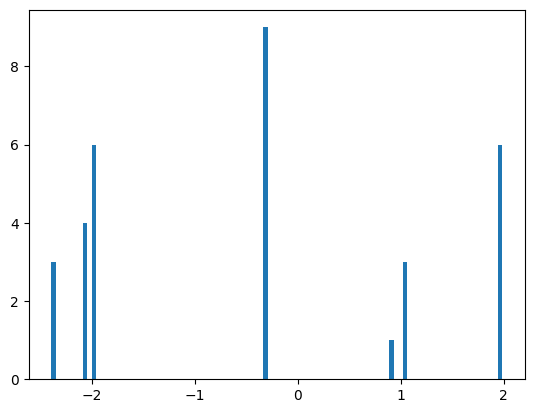

In [36]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)

In [100]:
l1_for_task0[neuron_mask][10]

tensor([ 2.4766, -2.4822, -2.4814,  2.4819, -2.4830])

tensor([ 2.8610e-06,  9.5367e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         9.5367e-07,  0.0000e+00,  9.5367e-07,  0.0000e+00,  9.5367e-07,
        -9.5367e-07,  0.0000e+00,  3.8147e-06,  0.0000e+00,  9.5367e-07,
        -9.5367e-07])

In [65]:
l1_for_task0[neuron_mask].shape

torch.Size([11, 5])

In [56]:
# plt.plot(l2_synth[neuron_mask].sort().values.abs())

14

In [22]:
torch.tensor(2, dtype=torch.float).norm(2)

tensor(2.)

<Axes: >

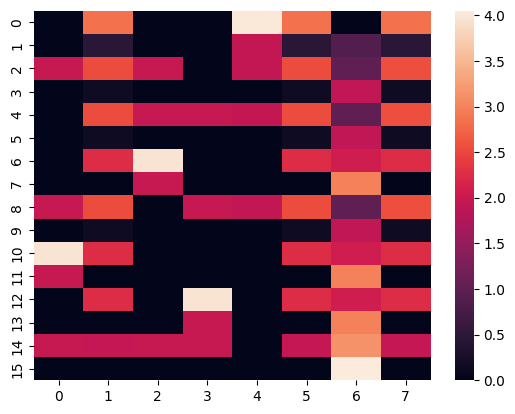

In [37]:
sns.heatmap(F.relu(input=x2))

<Axes: >

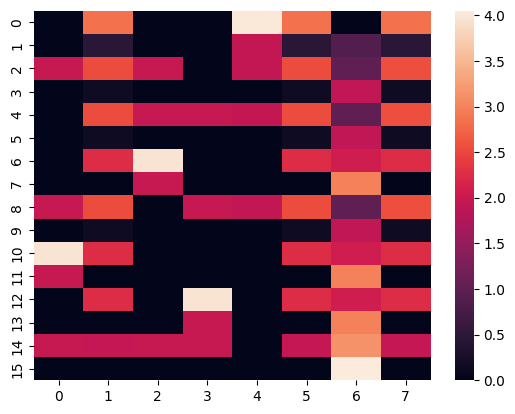

In [38]:
sns.heatmap(F.relu(input=x2))

In [22]:
a = F.relu(input=x2) @ ((l2_synth > 0) * 2 - 1).float()
a

tensor([ 0.9016, -2.0912,  0.0547,  0.9204, -1.4292, -0.0093,  1.6414, -0.4008,
        -0.8184, -0.1702,  1.6079, -0.2051,  3.7027, -1.3897, -0.2228,  2.0841])

In [23]:
(bits.sum(-1) % 2 == 0) == (a > 0)

tensor([ True,  True, False,  True,  True, False,  True,  True,  True, False,
         True,  True,  True,  True,  True,  True])

In [24]:
bits

tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 1]])

<Axes: >

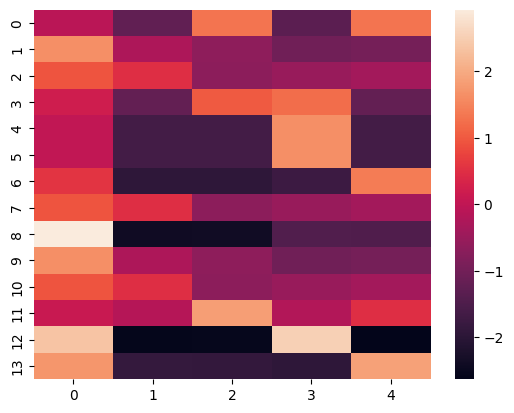

In [25]:
sns.heatmap(l1_for_task0)

<Axes: >

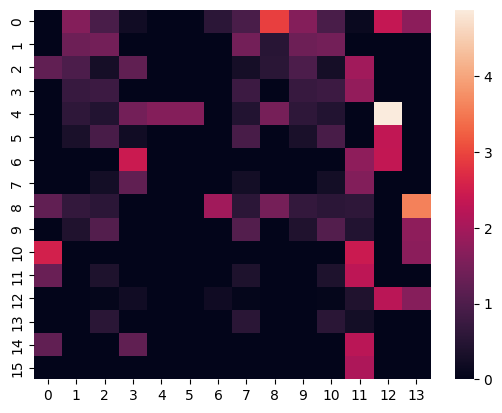

In [26]:
sns.heatmap(F.relu(input=x2))

<Axes: >

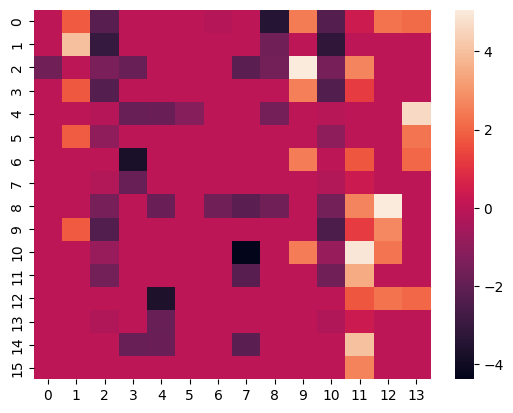

In [ ]:
# sns.heatmap((F.relu(input=x2) * l2_synth))
sns.heatmap((F.relu(input=x2) * ((l2_synth > 0) * 2 - 1)))

In [123]:
x4

tensor([ 17.6185, -11.8157, -15.4918,  15.6542, -13.2808,  19.9999,  11.8941,
        -15.3787, -15.1771,  15.5628,  18.5022, -15.0493,  11.9677, -15.2677,
        -24.1513,  13.5810])

In [ ]:
model.l1.weight[torch,]

IndexError: index 33 is out of bounds for dimension 0 with size 31

In [47]:
l2_synth @ model.l1.weight.data[:, 0]

tensor(18.6701)

In [48]:
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x4

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

In [15]:
batch_sz = 1
task_ids = torch.tensor([0])
bits = torch.tensor([0, 0, 0, 0])
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[0, dataset.selected_bits_by_task[0]] = bits

In [49]:
task_id = 0
batch_sz = 2**config.n_xored_bits
task_ids = torch.tensor([task_id]).repeat(batch_sz)
# bits = torch.tensor([0,0,0,0])
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[task_id]] = bits

In [50]:
# l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = x3 @ l2_synth

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

x4

tensor([ 17.6185, -15.1771, -15.4918,  18.5022, -13.2808,  11.9677,  11.8941,
        -24.1513, -11.8157,  15.5628,  15.6542, -15.0493,  19.9999, -15.2677,
        -15.3787,  13.5810])

In [57]:
l2_synth @ F.relu(model.l1.weight.data[:, 0])

tensor(17.6185)

<Axes: >

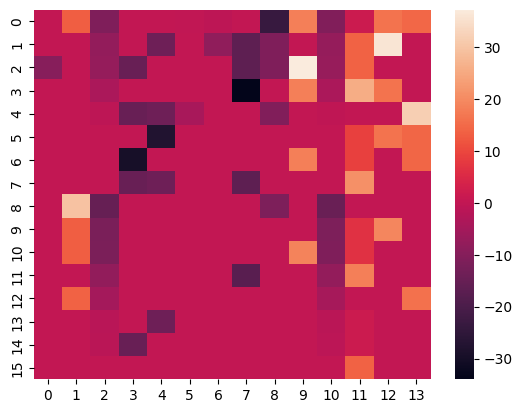

In [65]:
sns.heatmap((x3 * l2_synth))

In [139]:
dataset.selected_bits_by_task[0]

tensor([ 7, 17, 21, 16])

In [140]:
model.l1.weight.data[[17]].shape

torch.Size([1, 40])

<Axes: >

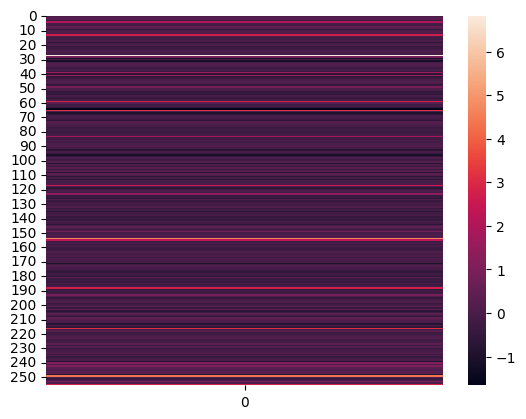

In [141]:
sns.heatmap(model.l1.weight.data[:, [0]])


<Axes: >

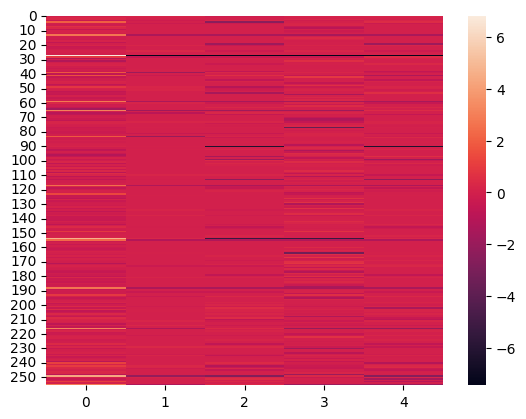

In [ ]:
sns.heatmap(
    model.l1.weight.data[:, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0] + 10])]
)

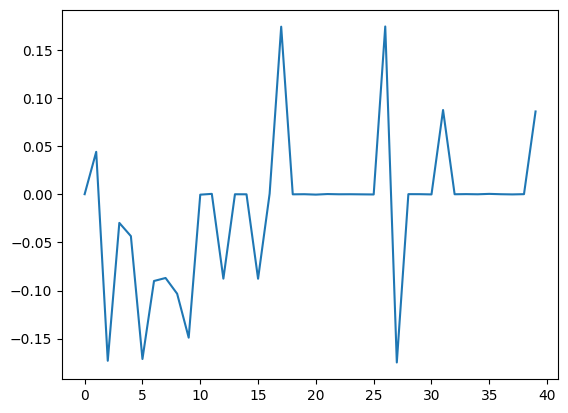

In [143]:
plt.plot(model.l1.weight.data[0])

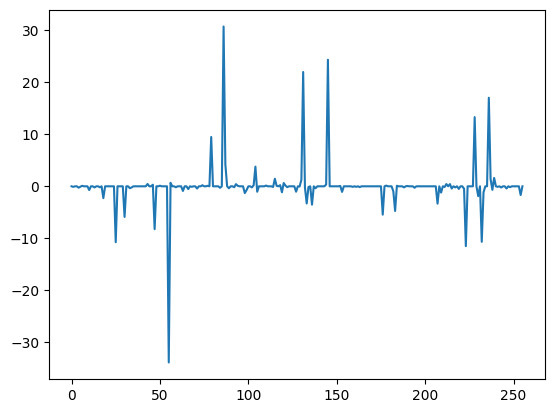

In [146]:
plt.plot((x3 * l2_synth)[0])
# plt.plot((x3 * l2_synth)[1])
# plt.plot((x3 * l2_synth)[2])
# plt.plot((x3 * l2_synth)[3])
# plt.plot((x3 * l2_synth)[14])
# plt.plot((x3 * l2_synth)[15])

In [119]:
(x3 * l2_synth)[15].sum()

tensor(9.2621)

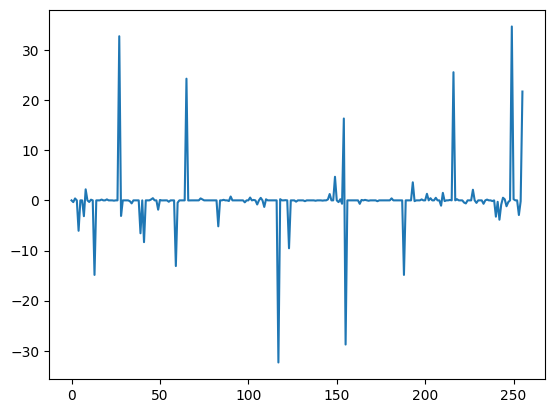

In [24]:
plt.plot((x3 * l2_synth)[0])

In [15]:
l2_synth.shape

torch.Size([256])

In [16]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [17]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [ ]:
einops.einsum(model.l2.weight.data, x3, 'two '

torch.Size([2, 256])

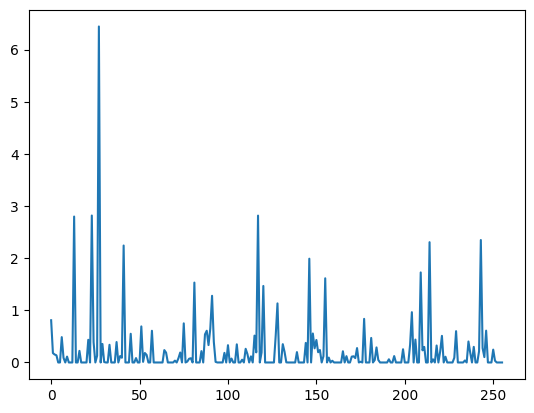

In [21]:
plt.plot(x3[0])

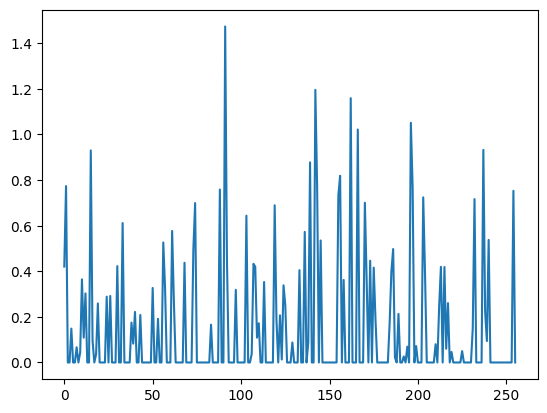

In [121]:
plt.plot(x3[0].detach())

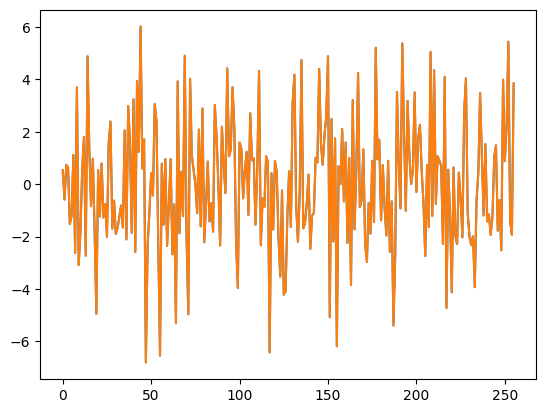

In [20]:
plt.plot(model.l2.weight.data[0])
plt.plot(-model.l2.weight.data[1])

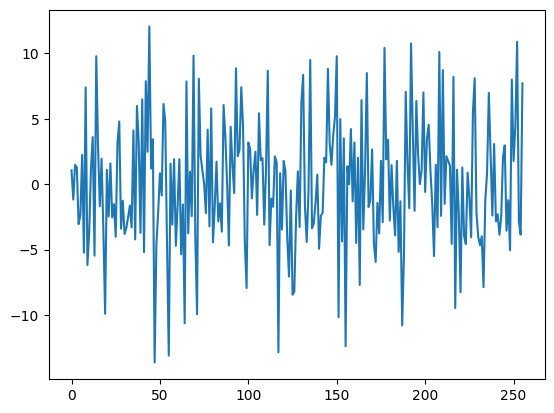

In [19]:
plt.plot(model.l2.weight.data[0] - model.l2.weight.data[1])

In [61]:
torch.randint(2, (1, config.n_xored_bits))

tensor([[1, 1, 1, 0]])

In [22]:
# plt.plot((model.l2.weight.data[0] - model.l2.weight.data[1]))
# plt.plot(model.l1.bias.data)

<Axes: >

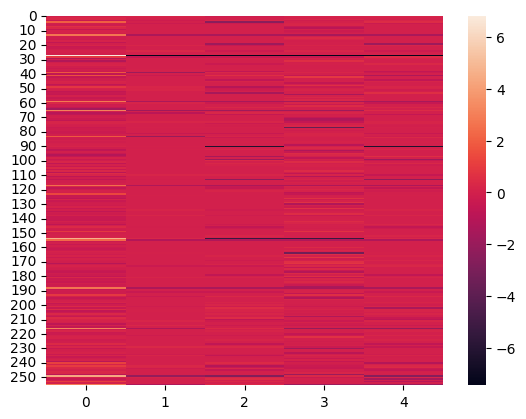

In [23]:
sns.heatmap(model.l1.weight.data[:, [0, 10 + 7, 10 + 17, 10 + 21, 10 + 16]])

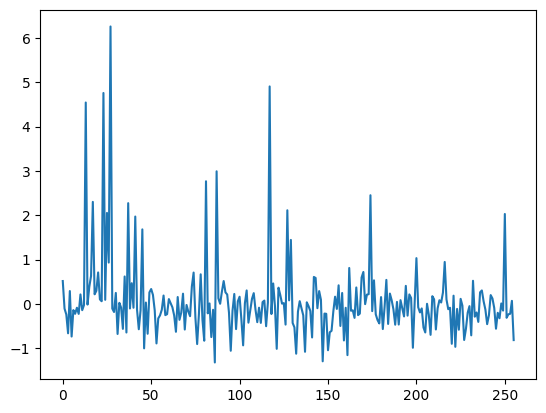

In [37]:
plt.plot(model.l1.weight.data[:, 0])

<Axes: >

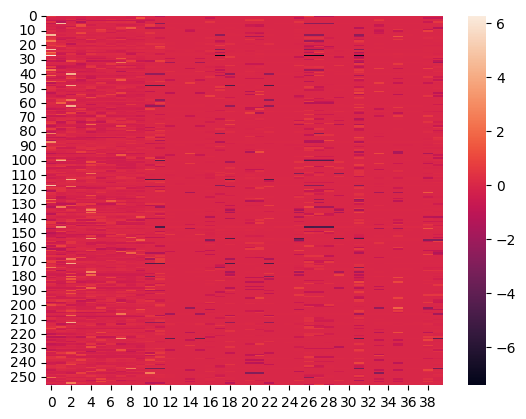

In [6]:
sns.heatmap(model.l1.weight.data)

In [7]:
(torch.arange(10, dtype=torch.float) + 1) ** -(0.4)

tensor([1.0000, 0.7579, 0.6444, 0.5743, 0.5253, 0.4884, 0.4592, 0.4353, 0.4152,
        0.3981])

In [ ]:
(torch.arange(10, dtype=torch.float) + 1) ** -(1 + 0.4)

tensor([1.0000, 0.3789, 0.2148, 0.1436, 0.1051, 0.0814, 0.0656, 0.0544, 0.0461,
        0.0398])